# 🪐 Dask — Parallel and Larger-than-Memory Python

> **What you'll learn:** how Dask splits work into **task graphs** that run lazily in parallel, how `dask.array` **chunks** and `dask.dataframe` **partitions** work, why **shuffles** are expensive, how to parallelize custom code with `dask.delayed`, how the **distributed scheduler** (`LocalCluster`, `Client`, futures, `persist`) works — and, just as important, **when Dask is not worth it**. Everything runs on 9.5 million real NYC taxi trips, with measured time and memory.

> 📌 **Optional notebook.** For most single-machine work, [Polars](01_Polars.ipynb) or DuckDB is simpler and faster. Study this one if you need parallel *Python* code, a path from a laptop to a cluster, or you expect Dask/Spark questions in interviews.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Interview-level |
| **Time** | ~3 hours to read and run, +1.5 hours for exercises and the project |
| **Prerequisites** | [Polars](01_Polars.ipynb) (lazy plans, pushdown) · [Pandas](../01_Core_Scientific_Computing/02_Pandas.ipynb) (DataFrames, `groupby`) |
| **Tested with** | Python 3.12 · dask 2026.8 · distributed 2026.8 · pandas 3.0 · pyarrow 25 · polars 1.44 · duckdb 1.5 |
| **Interview relevance** | ⭐⭐ Medium — partitions and shuffles, lazy task graphs, `persist` vs `compute`, "process data bigger than RAM", choosing pandas / Polars / DuckDB / Dask / Spark |

## 🤔 What Is Dask?

**Dask** is a Python library that runs your NumPy, pandas, or plain Python code **in parallel** — on all the cores of your laptop, or on a cluster of many machines — and on data **bigger than your RAM**.

Imagine a teacher with 3,000 exam papers to grade. Alone, it takes all weekend. Instead the teacher:
1. splits the pile into **stacks** (chunks / partitions),
2. writes a **plan**: "each assistant grades one stack, then I add up the totals" (a **task graph**),
3. hands stacks to **assistants** (workers) and keeps track of who is doing what (the **scheduler**).

No assistant ever holds all 3,000 papers, and several stacks are graded at the same time.

| Term | Plain-English meaning |
|---|---|
| **Task** | one function call on some inputs, e.g. "read file 2" |
| **Task graph** | all tasks plus which ones depend on which (a DAG — a graph with no cycles) |
| **Lazy** | building the graph does no work; `.compute()` runs it |
| **Chunk** (`dask.array`) / **Partition** (`dask.dataframe`) | one piece of the data — a normal NumPy array or pandas DataFrame |
| **Scheduler** | decides the order and where each task runs (threads, processes, or a cluster) |
| **Worker** | a process that executes tasks and holds results in memory |

```
         files / chunks                 tasks                       result
  Jan.parquet ──► read ──► clean ──► sum,count ─┐
  Feb.parquet ──► read ──► clean ──► sum,count ─┼──► combine ──► mean per zone
  Mar.parquet ──► read ──► clean ──► sum,count ─┘
                 (these three rows run in parallel)
```

## 🎯 Why It Matters

- **Scale familiar code.** `dask.dataframe` mirrors the pandas API and `dask.array` mirrors NumPy, so existing code often scales with small changes. Xarray (climate and satellite data), RAPIDS (GPUs), and many scientific pipelines are built on Dask.
- **Parallel custom Python.** Simulations, feature extraction, calling a model on thousands of files — `dask.delayed` and futures parallelize any function, not just DataFrame operations.
- **Laptop → cluster with the same code.** Swap `LocalCluster` for a Kubernetes, HPC, or cloud cluster; the analysis code stays the same.
- **In interviews** you will be asked: *"What is a shuffle and why is it expensive?"*, *"persist vs compute?"*, *"How do you process 500 GB on a laptop?"*, *"Dask or Spark?"*, and *"Threads or processes for this workload?"* Knowing when **not** to distribute (the data fits in memory) is a senior-level signal.

## ✅ By the End You Can

- [ ] Explain task graphs, laziness, chunks, partitions, and the three kinds of schedulers
- [ ] Read Parquet with Dask, use `map_partitions`, and predict which operations are cheap (tree reductions) and which need a **shuffle**
- [ ] Parallelize custom code over real file chunks with `dask.delayed` and futures, and pick threads vs processes
- [ ] Run a `LocalCluster`, use `Client`, futures, `persist` vs `compute`, and size partitions for memory
- [ ] Build an out-of-core group-by from scratch and measure honestly whether Dask beats pandas on your machine

## 📋 Table of Contents

1. [When Do You Need Dask?](#1.-When-Do-You-Need-Dask?-🟢)
2. [Task Graphs and Laziness](#2.-Task-Graphs-and-Laziness-🟢)
3. [dask.array: Chunked NumPy](#3.-dask.array:-Chunked-NumPy-🟢)
4. [dask.dataframe: Partitions and Parquet](#4.-dask.dataframe:-Partitions-and-Parquet-🟡)
5. [map_partitions: Your pandas Code on Every Partition](#5.-map_partitions:-Your-pandas-Code-on-Every-Partition-🟡)
6. [GroupBy Aggregations and Tree Reduction](#6.-GroupBy-Aggregations-and-Tree-Reduction-🟡)
7. [Shuffles, set_index, and Divisions](#7.-Shuffles,-set_index,-and-Divisions-🔴)
8. [dask.delayed on Real Chunks](#8.-dask.delayed-on-Real-Chunks-🟡)
9. [The Distributed Scheduler: LocalCluster, Client, Futures, persist](#9.-The-Distributed-Scheduler:-LocalCluster,-Client,-Futures,-persist-🔴)
10. [Memory and Partition Sizing](#10.-Memory-and-Partition-Sizing-🟡)
11. [Decision Guide: pandas vs Polars vs DuckDB vs Dask vs Spark](#11.-Decision-Guide:-pandas-vs-Polars-vs-DuckDB-vs-Dask-vs-Spark-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Three-Months-of-Taxi-Trips-—-Dask-vs-pandas-on-This-Laptop) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- Data is cached in `_outputs/nyc_taxi/` — the same folder the Polars notebook uses, so January is not downloaded twice.
- `run_in_fresh_process(fn, ...)` runs a function in a **new Python process** and reports wall time and **peak memory** (RSS summed over the process and any worker processes it starts). Fresh processes make memory comparisons fair.
- `check()` gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint). It accepts a pandas DataFrame or Series, a list of rows, a tuple (one row), or a single value — **call `.compute()` first** on Dask objects.

In [1]:
# %pip install -q "dask[dataframe,distributed]>=2025.1" "pandas>=3.0" "pyarrow>=20" "polars>=1.30" "duckdb>=1.3" psutil cloudpickle matplotlib

import gc
import importlib.util
import math
import os
import pickle
import subprocess
import sys
import threading
import time
import urllib.request
from pathlib import Path

import cloudpickle
import dask
import dask.array as da
import dask.dataframe as dd
import distributed
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import psutil
import pyarrow.parquet as pq
from dask import delayed
from dask.distributed import Client, LocalCluster, as_completed, wait

print(f"Python {sys.version.split()[0]} | dask {dask.__version__} | distributed {distributed.__version__} | "
      f"pandas {pd.__version__} | polars {pl.__version__} | duckdb {duckdb.__version__}")
TOTAL_RAM_GB = psutil.virtual_memory().total / 2**30
print(f"CPU cores: {os.cpu_count()} | RAM: {TOTAL_RAM_GB:.0f} GiB")

OUTPUT_DIR = Path("_outputs")                          # files we write go here (ignored by git)
DATA_DIR = OUTPUT_DIR / "nyc_taxi"
DATA_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 120)

_CHILD = ("import cloudpickle, pickle, sys; fn, args = cloudpickle.load(sys.stdin.buffer); "
          "sys.stdout.buffer.write(pickle.dumps(fn(*args)))")


def run_in_fresh_process(fn, *args, interval=0.01):
    """Run fn(*args) in a new Python process. Returns (result, wall_seconds, peak_rss_MB of the process tree)."""
    start = time.perf_counter()
    proc = subprocess.Popen([sys.executable, "-c", _CHILD], stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    peak = 0

    def sample():
        nonlocal peak
        parent = psutil.Process(proc.pid)
        while proc.poll() is None:
            try:
                rss = parent.memory_info().rss + sum(c.memory_info().rss for c in parent.children(recursive=True))
                peak = max(peak, rss)
            except psutil.Error:
                pass
            time.sleep(interval)

    sampler = threading.Thread(target=sample)
    sampler.start()
    out, err = proc.communicate(cloudpickle.dumps((fn, args)))
    sampler.join()
    if proc.returncode != 0:
        raise RuntimeError(err.decode()[-1500:])
    return pickle.loads(out), time.perf_counter() - start, peak / 1e6


def _rows(value):
    if hasattr(value, "__dask_graph__"):
        raise AssertionError("❌ this is still a lazy Dask object — call .compute() first")
    if isinstance(value, pd.DataFrame):
        return list(value.itertuples(index=False, name=None))
    if isinstance(value, pd.Series):
        return list(value.items())
    if isinstance(value, list):
        return [tuple(v) if isinstance(v, (list, tuple)) else (v,) for v in value]
    if isinstance(value, tuple):
        return [value]
    return [(value,)]


def _same(a, b):
    if isinstance(a, (int, float, np.integer, np.floating)) and isinstance(b, (int, float, np.integer, np.floating)):
        return math.isclose(float(a), float(b), rel_tol=1e-6, abs_tol=1e-9)
    return a == b


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_rows, exp_rows = _rows(got), _rows(expected)
    if len(got_rows) != len(exp_rows):
        raise AssertionError(f"❌ {name}: got {len(got_rows)} row(s), expected {len(exp_rows)}. {hint}")
    for g, e in zip(got_rows, exp_rows):
        if len(g) != len(e) or not all(_same(x, y) for x, y in zip(g, e)):
            raise AssertionError(f"❌ {name}: row {g} is not quite right (check columns, order, rounding). {hint}")
    print(f"✅ {name}: correct!")

Python 3.12.11 | dask 2026.8.0 | distributed 2026.8.0 | pandas 3.0.5 | polars 1.44.2 | duckdb 1.5.5
CPU cores: 15 | RAM: 24 GiB


## 1. When Do You Need Dask? 🟢

Reach for Dask when at least one of these is true:

1. **The data doesn't fit in memory** (or leaves too little headroom), and you can't reduce it with column selection and filters first.
2. **The work is CPU-bound and splits naturally** — many files, many parameter settings, many independent simulations — and one core is too slow.
3. **You need to grow beyond one machine** without rewriting the code.

If none is true, pandas, Polars, or DuckDB will usually be simpler **and faster** — Dask adds scheduling overhead to every task.

We use the official **NYC TLC yellow-taxi trip records** for **January–March 2024**: three Parquet files, ~160 MB on disk, ~9.5 M rows. The row count of each file is checked against its Parquet metadata.

In [2]:
TLC = "https://d37ci6vzurychx.cloudfront.net"
MONTHS = {"2024-01": 2_964_624, "2024-02": 3_007_526, "2024-03": 3_582_628}   # month → expected rows


def download(url, path, expected_rows=None):
    if not path.exists():
        request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (course notebook)"})
        with urllib.request.urlopen(request, timeout=180) as resp:
            path.write_bytes(resp.read())
        print(f"downloaded {path.name} ({path.stat().st_size / 1e6:.1f} MB)")
    if expected_rows is not None and (rows := pq.ParquetFile(path).metadata.num_rows) != expected_rows:
        raise RuntimeError(f"{path.name} has {rows:,} rows, expected {expected_rows:,}. TLC may have revised it: "
                           f"delete the file and re-run, and expect exercise answers to differ slightly.")
    return path


FILES = [str(download(f"{TLC}/trip-data/yellow_tripdata_{m}.parquet", DATA_DIR / f"yellow_tripdata_{m}.parquet", n).resolve())
         for m, n in MONTHS.items()]
ZONES_PATH = download(f"{TLC}/misc/taxi_zone_lookup.csv", DATA_DIR / "taxi_zone_lookup.csv")
TOTAL_ROWS = sum(MONTHS.values())
disk_mb = sum(Path(f).stat().st_size for f in FILES) / 1e6
print(f"✅ {len(FILES)} monthly files | {disk_mb:.0f} MB on disk | {TOTAL_ROWS:,} rows")

✅ 3 monthly files | 160 MB on disk | 9,554,778 rows


In [3]:
# How big would this be in pandas? Measure one month, then extrapolate.
jan = pd.read_parquet(FILES[0])
bytes_per_row = jan.memory_usage(deep=True).sum() / len(jan)
three_months_gb = bytes_per_row * TOTAL_ROWS / 2**30
year_gb = bytes_per_row * TOTAL_ROWS * 4 / 2**30
print(f"pandas needs {bytes_per_row:.0f} bytes per row (all 19 columns) → 3 months ≈ {three_months_gb:.1f} GiB, "
      f"a year ≈ {year_gb:.1f} GiB | this machine has {TOTAL_RAM_GB:.0f} GiB")
print(f"Parquet on disk is {bytes_per_row * len(jan) / Path(FILES[0]).stat().st_size:.1f}× smaller than pandas in memory (compression + encoding)")
if three_months_gb < 0.25 * TOTAL_RAM_GB:
    print("→ 3 months fits comfortably in memory, so Dask is OPTIONAL here: we use it to learn the ideas and to measure its overhead honestly.")
else:
    print("→ 3 months is a large share of RAM: out-of-core tools (Dask, Polars streaming, DuckDB) are genuinely needed here.")
del jan

pandas needs 141 bytes per row (all 19 columns) → 3 months ≈ 1.3 GiB, a year ≈ 5.0 GiB | this machine has 24 GiB
Parquet on disk is 8.4× smaller than pandas in memory (compression + encoding)
→ 3 months fits comfortably in memory, so Dask is OPTIONAL here: we use it to learn the ideas and to measure its overhead honestly.


> 💡 **Interview angle:** "Your data is 40 GB and the machine has 16 GB. What do you do?" — first *shrink*: read only needed columns, filter early, use smaller dtypes, or aggregate in a streaming engine (Polars/DuckDB). Use Dask (or Spark) when the work truly can't be reduced to fit, or when you need parallel Python across many machines.

## 2. Task Graphs and Laziness 🟢

`dask.delayed` wraps a normal function so that calling it **records a task** instead of running it. Calling delayed functions on the results of other delayed functions builds a **task graph**. Nothing runs until `.compute()`.

```
  rows_jan ─┐
  rows_feb ─┼──► total_rows          .compute() → the scheduler runs the three
  rows_mar ─┘                         leaf tasks in parallel, then the sum
```

In [4]:
@delayed
def count_rows(path):
    return pq.ParquetFile(path).metadata.num_rows          # cheap: reads only the file footer


@delayed
def add_all(counts):
    return sum(counts)


counts = [count_rows(f) for f in FILES]
total = add_all(counts)
print("before compute:", total)                             # a Delayed object, not a number


def describe_graph(obj):
    """Print each task in a Dask graph with the tasks it depends on."""
    graph = dict(obj.__dask_graph__())
    short = lambda k: (k if isinstance(k, str) else "-".join(map(str, k)))[:22]
    print(f"{len(graph)} tasks:")
    for key, node in graph.items():
        deps = sorted(short(d) for d in getattr(node, "dependencies", ()))
        print(f"  {short(key):24s} ← depends on {deps if deps else 'nothing (a leaf)'}")


describe_graph(total)
print("after compute :", f"{total.compute():,}")

before compute: Delayed('add_all-999bec4c-b635-4e26-bad1-1f5dbd094bd8')
4 tasks:
  add_all-999bec4c-b635-   ← depends on ['count_rows-1dee3d2f-79', 'count_rows-55c8d611-78', 'count_rows-9121cbf6-bc']
  count_rows-9121cbf6-bc   ← depends on nothing (a leaf)
  count_rows-55c8d611-78   ← depends on nothing (a leaf)
  count_rows-1dee3d2f-79   ← depends on nothing (a leaf)
after compute : 9,554,778


**Sharing work.** When two results depend on the same expensive step, compute them **together** with `dask.compute(a, b)`: the shared step runs once. Calling `.compute()` separately runs it twice. We count real function calls to prove it.

In [5]:
calls = []


@delayed
def load_january(columns):
    calls.append("load")                                   # record every real call
    return pd.read_parquet(FILES[0], columns=columns)


trips_jan = load_january(["fare_amount", "tip_amount"])
mean_fare = trips_jan["fare_amount"].mean()                # delayed objects support attribute/item access
mean_tip = trips_jan["tip_amount"].mean()

calls.clear(); separate = (mean_fare.compute(), mean_tip.compute()); n_separate = len(calls)
calls.clear(); together = dask.compute(mean_fare, mean_tip); n_together = len(calls)
assert np.allclose(separate, together)
print(f"separate .compute() calls loaded the file {n_separate}× | dask.compute(a, b) loaded it {n_together}×")
print(f"mean fare ${together[0]:.2f}, mean tip ${together[1]:.2f}")

separate .compute() calls loaded the file 2× | dask.compute(a, b) loaded it 1×
mean fare $18.18, mean tip $3.34


### ✍️ Your Turn

Use `dask.delayed` to compute the **total `fare_amount` across the three files**, with **one task per file** that reads just that column and sums it, plus one task that adds the three sums. Store the computed float in `total_fare`.

In [6]:
total_fare = None  # TODO: your code here
check("total_fare", total_fare, 175_092_421.01,
      hint="@delayed def file_fare_sum(path): return pd.read_parquet(path, columns=['fare_amount'])['fare_amount'].sum(); then sum of the delayed list")

⏳ total_fare: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
@delayed
def file_fare_sum(path):
    return pd.read_parquet(path, columns=["fare_amount"])["fare_amount"].sum()

total_fare = delayed(sum)([file_fare_sum(f) for f in FILES]).compute()
check("total_fare", total_fare, 175_092_421.01)
```

`delayed(sum)(list_of_delayed)` creates the final task; Dask sees that the list contains delayed values and wires them in as dependencies.
</details>

> 💡 **Interview angle:** "What does lazy evaluation buy you in Dask?" — the whole graph is known before running, so the scheduler can run independent tasks in parallel, share common steps, release memory as soon as a result is no longer needed, and (for DataFrames) optimize the plan.

## 3. dask.array: Chunked NumPy 🟢

A `dask.array` is a grid of normal NumPy arrays called **chunks**. Element-wise math runs chunk by chunk; aggregations like `mean` compute partial results per chunk (sum and count) and combine them.

```
  fare array (9.5 M values)
  [ Jan chunk: 2.96 M ][ Feb chunk: 3.01 M ][ Mar chunk: 3.58 M ]
        mean → (sum, count) per chunk → add sums, add counts → divide
```

We build the array **lazily from the files**: the chunk sizes come from Parquet metadata, so no data is read until we compute.

In [7]:
def read_column(path, column):
    return pq.read_table(path, columns=[column]).column(column).to_numpy()


fare = da.concatenate([
    da.from_delayed(delayed(read_column)(f, "fare_amount"), shape=(pq.ParquetFile(f).metadata.num_rows,), dtype="float64")
    for f in FILES
])
print(fare)
print("chunks:", fare.chunks, "| number of blocks:", fare.numblocks)

start = time.perf_counter()
fare_mean, fare_std = dask.compute(fare.mean(), fare.std())
dask_s = time.perf_counter() - start
exact = np.concatenate([read_column(f, "fare_amount") for f in FILES])
assert np.isclose(fare_mean, exact.mean()) and np.isclose(fare_std, exact.std())
print(f"mean fare ${fare_mean:.2f} ± {fare_std:.2f} (matches NumPy on the full array) | Dask took {dask_s * 1000:.0f} ms")
del exact

dask.array<concatenate, shape=(9554778,), dtype=float64, chunksize=(3582628,), chunktype=numpy.ndarray>
chunks: ((2964624, 3007526, 3582628),) | number of blocks: (3,)


mean fare $18.33 ± 18.54 (matches NumPy on the full array) | Dask took 100 ms


In [8]:
# Chunk mechanics on a synthetic array (a controlled example)
x = da.arange(10_000_000, chunks=2_500_000)
print("chunks:", x.chunks, "| tasks for (x ** 2).sum():", len((x ** 2).sum().__dask_graph__()))
print("block 1 (a real NumPy array once computed):", x.blocks[1].compute()[:3], "…")
y = x.rechunk(5_000_000)
print("after rechunk:", y.chunks, "| tasks now:", len((y ** 2).sum().__dask_graph__()))
print("map_blocks runs any NumPy function per chunk:", x.map_blocks(lambda block: block % 7, dtype=x.dtype).sum().compute())

chunks: ((2500000, 2500000, 2500000, 2500000),) | tasks for (x ** 2).sum(): 13
block 1 (a real NumPy array once computed): [2500000 2500001 2500002] …
after rechunk: ((5000000, 5000000),) | tasks now: 11
map_blocks runs any NumPy function per chunk: 29999994


**Chunk size is a trade-off.** Too small → thousands of tiny tasks, and scheduling overhead dominates. Too large → each chunk may not fit in a worker's memory and there is less parallelism. Tens to a few hundred MB per chunk is a common starting point.

### ✍️ Your Turn

Using the chunked `fare` array (not NumPy), compute the **share of trips with a fare above $50**. Store the float in `share_over_50`.

In [9]:
share_over_50 = None  # TODO: your code here
check("share_over_50", share_over_50, 0.06185188185429321, hint="(fare > 50).mean().compute() — booleans average to a share")

⏳ share_over_50: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
share_over_50 = float((fare > 50).mean().compute())
check("share_over_50", share_over_50, 0.06185188185429321)
```
</details>

> 💡 **Interview angle:** "How would you compute the mean of a 1 TB array?" — split it into chunks, compute (sum, count) per chunk in parallel, combine; only two numbers per chunk ever travel back. The same pattern (map → combine → reduce) underlies MapReduce and Spark.

## 4. dask.dataframe: Partitions and Parquet 🟡

A Dask DataFrame is a sequence of **pandas DataFrames** called **partitions**, plus optional **divisions** — the index values where each partition starts and ends (unknown unless the data is sorted by the index).

```
 Dask DataFrame  ──►  partition 0 (pandas, Jan)  | partition 1 (pandas, Feb) | partition 2 (pandas, Mar)
```

Since 2024 Dask DataFrame has used a **query optimizer** (the `dask-expr` project, now part of Dask itself): like Polars' lazy API, it rewrites your expression — for example pushing column selection into the Parquet reader — before building tasks.

In [10]:
ddf = dd.read_parquet(FILES)
print(f"type: {type(ddf).__name__} | partitions: {ddf.npartitions} | known divisions: {ddf.known_divisions}")
print(ddf.dtypes.head(6))
print("\nrows per partition:", ddf.map_partitions(len).compute().tolist())
ddf.head(3)                                                 # reads only what it needs from the first partition

type: DataFrame | partitions: 3 | known divisions: False
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
dtype: object



rows per partition: [2964624, 3007526, 3582628]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0


In [11]:
import contextlib
import io


def show_plan(expr):
    """Print a Dask plan with the long absolute data-folder path shortened, so plans stay readable."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        expr.pprint()
    print(buffer.getvalue().replace(str(DATA_DIR.resolve()), str(DATA_DIR)))


query = ddf[ddf["payment_type"] == 1][["PULocationID", "tip_amount"]].groupby("PULocationID")["tip_amount"].mean()
print("── expression as written ──")
show_plan(query)
print("\n── after the optimizer (fuse=False keeps steps visible) ──")
show_plan(query.optimize(fuse=False))

── expression as written ──
Projection: columns='tip_amount'
  Mean: observed=True chunk_kwargs={'numeric_only': False} aggregate_kwargs={'numeric_only': False} _slice='tip_amount''PULocationID'
    Projection: columns=['PULocationID', 'tip_amount']
      Projection: columns=['PULocationID', 'tip_amount']
        Filter:
          ReadParquetFSSpec: path=['_outputs/nyc_taxi/yellow_tripdata_2024-01.parquet', '_outputs/nyc_taxi/yellow_tripdata_2024-02.parquet', '_outputs/nyc_taxi/yellow_tripdata_2024-03.parquet']
          EQ: right=1
            Projection: columns='payment_type'
              ReadParquetFSSpec: path=['_outputs/nyc_taxi/yellow_tripdata_2024-01.parquet', '_outputs/nyc_taxi/yellow_tripdata_2024-02.parquet', '_outputs/nyc_taxi/yellow_tripdata_2024-03.parquet']


── after the optimizer (fuse=False keeps steps visible) ──
Projection: columns='tip_amount'
  Mean(TreeReduce): split_every=8
    Mean(GroupByChunk): observed=True
      Filter:
        Projection: columns=['PULoca

Read the optimized plan bottom-up: the `ReadParquet…` node now lists only the **columns** the query needs — projection pushdown, like Polars' `PROJECT 3/19 COLUMNS`.

**Counting rows.** `len(ddf)` needs no data at all for Parquet: the optimizer answers it from the file metadata.

In [12]:
row_count = ddf.shape[0]
print("the optimized expression for ddf.shape[0]:")
row_count.optimize().pprint()
start = time.perf_counter(); n_len = len(ddf); t_len = time.perf_counter() - start
start = time.perf_counter(); n_shape = ddf.shape[0].compute(); t_shape = time.perf_counter() - start
print(f"len(ddf) = {n_len:,} in {t_len * 1000:.0f} ms | ddf.shape[0].compute() = {n_shape:,} in {t_shape * 1000:.0f} ms — the same work")

the optimized expression for ddf.shape[0]:
Fused(577d7):
| FloorDiv: right=19
|   Mul: left=19
      Literal: value=9554778
len(ddf) = 9,554,778 in 3 ms | ddf.shape[0].compute() = 9,554,778 in 2 ms — the same work


### ✍️ Your Turn

Across all three months, how many trips have a **missing `passenger_count`**? Compute it with Dask and store an integer in `n_missing_passengers`.

In [13]:
n_missing_passengers = None  # TODO: your code here
check("n_missing_passengers", n_missing_passengers, 751_962, hint="ddf['passenger_count'].isna().sum().compute()")

⏳ n_missing_passengers: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_missing_passengers = int(ddf["passenger_count"].isna().sum().compute())
check("n_missing_passengers", n_missing_passengers, 751_962)
```

Thanks to projection pushdown, only the `passenger_count` column is read.
</details>

> 💡 **Interview angle:** "How is a Dask DataFrame different from a pandas DataFrame?" — it's a lazy collection of many pandas partitions; operations build a graph that runs per partition in parallel. It has no cheap positional indexing (`iloc` across rows), and operations that need all data in one place (sorting, `set_index`, some joins) trigger an expensive shuffle.

## 5. map_partitions: Your pandas Code on Every Partition 🟡

`ddf.map_partitions(fn)` calls `fn(pandas_df)` on each partition and stitches the results into a new Dask collection. It's the escape hatch for any pandas logic Dask doesn't wrap.

Because Dask is lazy, it needs to know the **output schema** before running — the **`meta`** (an empty DataFrame with the right columns and dtypes). If you don't pass `meta=`, Dask guesses by running your function on a tiny fake DataFrame. Passing it yourself is faster and avoids wrong guesses.

In [14]:
def add_trip_features(df):
    """Plain pandas: runs on one partition at a time."""
    minutes = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
    return pd.DataFrame({
        "PULocationID": df["PULocationID"],
        "duration_min": minutes,
        "hour": df["tpep_pickup_datetime"].dt.hour,
        "tip_pct": (df["tip_amount"] / df["fare_amount"]).where(df["payment_type"] == 1),
    })


meta = add_trip_features(ddf._meta)                         # run the function on the empty schema → exact meta
features = ddf.map_partitions(add_trip_features, meta=meta)
first_partition = features.partitions[0].compute()          # .partitions[i] selects one partition
assert (first_partition.dtypes == features.dtypes).all(), "meta must match what the function really returns"
print(f"{features.npartitions} partitions | dtypes match the real output ✅")
print(first_partition.head(3))

mean_by_hour = features.groupby("hour")["duration_min"].mean().compute().sort_index()
print(f"\nlongest average trips start at {mean_by_hour.idxmax()}:00 ({mean_by_hour.max():.1f} min); "
      f"shortest at {mean_by_hour.idxmin()}:00 ({mean_by_hour.min():.1f} min)")

3 partitions | dtypes match the real output ✅
   PULocationID  duration_min  hour   tip_pct
0           186     19.800000     0       NaN
1           140      6.600000     0  0.375000
2           236     17.916667     0  0.128755



longest average trips start at 15:00 (18.6 min); shortest at 2:00 (12.9 min)


### ✍️ Your Turn

Using `map_partitions` on `ddf`, count **per partition** how many trips have a **tip larger than the fare**. Store the computed values as a Python list in `tip_gt_fare`.

In [15]:
tip_gt_fare = None  # TODO: your code here
check("tip_gt_fare", tip_gt_fare, [41_391, 44_354, 62_848],
      hint="ddf.map_partitions(lambda df: int((df['tip_amount'] > df['fare_amount']).sum())).compute().tolist()")

⏳ tip_gt_fare: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tip_gt_fare = ddf.map_partitions(lambda df: int((df["tip_amount"] > df["fare_amount"]).sum())).compute().tolist()
check("tip_gt_fare", tip_gt_fare, [41_391, 44_354, 62_848])
```

A function that returns a scalar per partition gives a Dask Series with one value per partition. (Many of these are trips with a $0 fare — flex-fare and no-charge records — which is worth a data-quality check.)
</details>

> 💡 **Interview angle:** "When would you use `map_partitions`?" — for row-wise or per-partition pandas logic that Dask doesn't expose (custom feature code, calling a model on each chunk). Mention `meta`: Dask must know the output schema lazily; pass it explicitly to avoid inference on fake data.

## 6. GroupBy Aggregations and Tree Reduction 🟡

How can a group-by mean run on partitions that never see each other? **Decompose** the aggregation:

```
  partition 0 ──► per zone: (sum, count) ─┐
  partition 1 ──► per zone: (sum, count) ─┼─► add sums and counts per zone ─► sum / count
  partition 2 ──► per zone: (sum, count) ─┘        (a "tree reduction")
```

`sum`, `count`, `mean`, `min`, `max`, `var`, `std` decompose this way and are cheap. Exact `median`, `nunique`, or arbitrary `apply` do **not**: rows of the same group must be brought together first — a **shuffle** (next section). With many groups, `split_out=` spreads the result over several output partitions.

In [16]:
tips_by_zone = (ddf[ddf["payment_type"] == 1]
                .groupby("PULocationID")
                .agg(trips=("tip_amount", "size"), mean_tip=("tip_amount", "mean"), max_tip=("tip_amount", "max")))
print("plan:")
tips_by_zone.optimize().pprint()

dask_tips = tips_by_zone.compute().sort_index()
cols = ["PULocationID", "payment_type", "tip_amount"]
pandas_tips = (pd.concat([pd.read_parquet(f, columns=cols) for f in FILES]).query("payment_type == 1")
               .groupby("PULocationID").agg(trips=("tip_amount", "size"), mean_tip=("tip_amount", "mean"), max_tip=("tip_amount", "max")))
pd.testing.assert_frame_equal(dask_tips, pandas_tips, check_dtype=False)
print(f"\n✅ identical to pandas for {len(dask_tips)} zones | top zone by card trips: {dask_tips['trips'].idxmax()} "
      f"({dask_tips['trips'].max():,} trips, mean tip ${dask_tips.loc[dask_tips['trips'].idxmax(), 'mean_tip']:.2f})")

plan:
ColumnsSetter: columns=('trips', 'mean_tip', 'max_tip')
  DecomposableGroupbyAggregation(TreeReduce): split_every=8
    Fused(78406):
    | DecomposableGroupbyAggregation(GroupByChunk): funcs=[('count-tip_amount-7b9ce493e8d710d27686c71de475d477', <function _apply_func_to_column at 0x1172cd4e0>, {'column': 'tip_amount', 'func': <methodcaller: count>}), ('max-tip_amount-215654840eb161febc31325317069e54', <function _apply_func_to_column at 0x1172cd4e0>, {'column': 'tip_amount', 'func': <methodcaller: max>}), ('size-tip_amount-251feb35a8033cb859fe8a6a03c91c98', <function _apply_func_to_column at 0x1172cd4e0>, {'column': 'tip_amount', 'func': <methodcaller: size>}), ('sum-tip_amount-e30703835f7ef5321a032c8f74715b48', <function _apply_func_to_column at 0x1172cd4e0>, {'column': 'tip_amount', 'func': <methodcaller: sum>})] observed=True
    |   Filter:
    |     EQ: right=1
    |       Projection: columns='payment_type'
    |         FusedIO:
    |     Projection: columns=['PULocationID'


✅ identical to pandas for 258 zones | top zone by card trips: 161 (359,396 trips, mean tip $3.86)


### ✍️ Your Turn

Compute the **mean `trip_distance` for payment types 1 (card) and 2 (cash)** across all months with Dask. Store a pandas Series indexed by `payment_type` (sorted by index) in `dist_by_payment`.

In [17]:
dist_by_payment = None  # TODO: your code here
check("dist_by_payment", dist_by_payment, [(1, 3.429249733885648), (2, 3.2372758466436875)],
      hint="filter with ddf['payment_type'].isin([1, 2]), groupby('payment_type')['trip_distance'].mean(), .compute().sort_index()")

⏳ dist_by_payment: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
dist_by_payment = (ddf[ddf["payment_type"].isin([1, 2])]
                   .groupby("payment_type")["trip_distance"].mean()
                   .compute().sort_index())
check("dist_by_payment", dist_by_payment, [(1, 3.429249733885648), (2, 3.2372758466436875)])
```
</details>

> 💡 **Interview angle:** "How does a distributed engine compute an average?" — never average the per-partition averages (partitions have different sizes); carry (sum, count) and combine. For `median` or distinct counts, say you'd either shuffle by key or use an approximate sketch (t-digest, HyperLogLog).

## 7. Shuffles, set_index, and Divisions 🔴

A **shuffle** moves rows between partitions so that all rows with the same key end up in the same partition. Every partition may send data to every other partition (an *all-to-all* exchange) — on a cluster that means network traffic, serialization, disk spill, and memory spikes. It's usually the most expensive thing a distributed job does.

Operations that shuffle: `set_index` / `sort_values`, `merge` of two large frames on non-index columns, `groupby(...).apply`, exact `nunique` / `median` per group, `drop_duplicates` with `split_out`.

In [18]:
distinct_dropoffs = ddf.groupby("PULocationID")["DOLocationID"].nunique()
mean_fare_by_zone = ddf.groupby("PULocationID")["fare_amount"].mean()
print("── nunique needs a shuffle ──")
distinct_dropoffs.optimize().pprint()

shuffle_cost = {}
for label, expr in [("mean (tree reduction)", mean_fare_by_zone), ("nunique (shuffle)", distinct_dropoffs)]:
    start = time.perf_counter()
    expr.compute()
    shuffle_cost[label] = (len(expr.__dask_graph__()), time.perf_counter() - start)
    print(f"{label:22s}: {shuffle_cost[label][0]:3d} tasks, {shuffle_cost[label][1]:.2f} s")
tasks_ratio = shuffle_cost["nunique (shuffle)"][0] / shuffle_cost["mean (tree reduction)"][0]
print(f"→ the shuffle needs {tasks_ratio:.1f}× the tasks. Here it runs in one process on {ddf.npartitions} partitions, so the time "
      "difference is small; on a cluster every shuffled row also crosses the network, which is where shuffles get expensive.")

── nunique needs a shuffle ──
Fused(3e434):
| NUnique(Aggregate): levels=0 name=DOLocationID
|   SetIndexBlockwise: other=['PULocationID']
|     Projection: columns=['PULocationID', 'DOLocationID']
        DiskShuffle: npartitions_out=2 original_partitioning_index=['PULocationID']
          Fused(1f4cb):
          | AssignPartitioningIndex: partitioning_index=['PULocationID'] npartitions_out=2 meta='<pandas>'
          |   ResetIndex:
          |     NUnique(GroupByChunk): chunk=None columns=DOLocationID observed=True name=DOLocationID
          |       FusedIO:


mean (tree reduction) :  11 tasks, 0.27 s


nunique (shuffle)     :  32 tasks, 0.22 s
→ the shuffle needs 2.9× the tasks. Here it runs in one process on 3 partitions, so the time difference is small; on a cluster every shuffled row also crosses the network, which is where shuffles get expensive.


**Divisions.** `set_index("tpep_pickup_datetime")` sorts the data by time (a shuffle) and records each partition's time range. With known divisions, a time filter only opens the partitions whose range overlaps it — **partition pruning**.

In [19]:
start = time.perf_counter()
by_time = (ddf[["tpep_pickup_datetime", "PULocationID", "fare_amount"]]
           .set_index("tpep_pickup_datetime", npartitions=12)          # sort into 12 time-ordered partitions
           .persist())
sort_s = time.perf_counter() - start
print(f"set_index + persist: {sort_s:.2f} s | known divisions: {by_time.known_divisions} | partitions: {by_time.npartitions}")
print("first divisions:", [str(d) for d in by_time.divisions[:3]], "…")

valentines = by_time.loc["2024-02-14"]
start = time.perf_counter(); n_valentines = len(valentines); loc_s = time.perf_counter() - start
print(f".loc['2024-02-14'] touches {valentines.npartitions} of {by_time.npartitions} partitions → {n_valentines:,} trips in {loc_s * 1000:.0f} ms")

set_index + persist: 1.24 s | known divisions: True | partitions: 12
first divisions: ['2002-12-31 22:17:10', '2024-01-09 08:09:19', '2024-01-17 10:45:38'] …
.loc['2024-02-14'] touches 1 of 12 partitions → 121,771 trips in 20 ms


Notice the first division: a pickup timestamp from **2002** (a broken taximeter clock). Sorting puts such outliers at the edge, which can make partitions uneven — real data is messy even for the engine.

### ✍️ Your Turn

Using `by_time` and `.loc`, count the trips picked up on **1 March 2024**. Store an integer in `n_march_first`.

In [20]:
n_march_first = None  # TODO: your code here
check("n_march_first", n_march_first, int(pl.scan_parquet(FILES).filter(pl.col("tpep_pickup_datetime").dt.date() == pl.date(2024, 3, 1)).select(pl.len()).collect().item()),
      hint="len(by_time.loc['2024-03-01'])")

⏳ n_march_first: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_march_first = len(by_time.loc["2024-03-01"])
check("n_march_first", n_march_first, int(pl.scan_parquet(FILES).filter(pl.col("tpep_pickup_datetime").dt.date() == pl.date(2024, 3, 1)).select(pl.len()).collect().item()))
```

The checker computes the expected value independently with Polars — a habit worth copying when you validate a distributed job.
</details>

In [21]:
del by_time, valentines                                     # release the persisted sorted copy

> 💡 **Interview angle:** "What is a shuffle and how do you avoid it?" — redistributing rows by key across partitions; avoid it by using decomposable aggregations, filtering and selecting columns *before* it, joining a large table to a small one with a broadcast join, keeping data partitioned/sorted by the key you join on (known divisions), and doing `set_index` once and persisting the result.

## 8. dask.delayed on Real Chunks 🟡

Use `delayed` when your work isn't a DataFrame or array operation. The rule that makes it fast: **one delayed task per chunk** (file, row group, parameter setting) — never one task wrapping the whole dataset.

**Threads or processes?** Python's **GIL** (global interpreter lock) lets only one thread run Python bytecode at a time.
- pandas/NumPy/Arrow do most work in C and **release the GIL** → **threads** parallelize well and share memory for free.
- Pure-Python loops hold the GIL → need **processes** (separate interpreters), which pay start-up and data-copying costs.

In [22]:
def month_zone_stats(path):
    """Read one month and return per-zone (sum, count) of positive fares — a partial result."""
    df = pd.read_parquet(path, columns=["PULocationID", "fare_amount"])
    return df[df["fare_amount"] > 0].groupby("PULocationID")["fare_amount"].agg(["sum", "count"])


def combine_stats(parts):
    total = pd.concat(parts).groupby(level=0).sum()
    return total["sum"] / total["count"]


timings, results = {}, {}
start = time.perf_counter(); results["serial loop"] = combine_stats([month_zone_stats(f) for f in FILES]); timings["serial loop"] = time.perf_counter() - start
graph = delayed(combine_stats)([delayed(month_zone_stats)(f) for f in FILES])
for scheduler in ["threads", "processes"]:
    start = time.perf_counter()
    results[scheduler] = graph.compute(scheduler=scheduler)
    timings[scheduler] = time.perf_counter() - start
for name in results:
    pd.testing.assert_series_equal(results[name], results["serial loop"])
    print(f"{name:12s}: {timings[name]:.2f} s")
print(f"→ fastest: {min(timings, key=timings.get)} (pandas work releases the GIL, so threads avoid the processes' start-up and copying costs)")

serial loop : 0.30 s
threads     : 0.10 s
processes   : 1.21 s
→ fastest: threads (pandas work releases the GIL, so threads avoid the processes' start-up and copying costs)


In [23]:
# The old notebook's bug: wrapping the WHOLE DataFrame in one delayed call
whole = pd.concat([pd.read_parquet(f, columns=["PULocationID", "fare_amount"]) for f in FILES], ignore_index=True)
one_task = delayed(lambda df: df[df["fare_amount"] > 0].groupby("PULocationID")["fare_amount"].mean())(whole)
per_file = delayed(combine_stats)([delayed(month_zone_stats)(f) for f in FILES])
print(f"❌ one delayed call on the whole DataFrame: {len(one_task.__dask_graph__())} task — nothing can run in parallel, "
      f"and all {len(whole):,} rows were loaded up front in this process")
print(f"✅ one delayed call per file: {len(per_file.__dask_graph__())} tasks — each file is read and processed independently")
pd.testing.assert_series_equal(one_task.compute().sort_index(), per_file.compute().sort_index(), check_names=False)
del whole

❌ one delayed call on the whole DataFrame: 1 task — nothing can run in parallel, and all 9,554,778 rows were loaded up front in this process
✅ one delayed call per file: 4 tasks — each file is read and processed independently


> 💡 **Interview angle:** "Threads or processes for this job?" — threads when the heavy lifting is in NumPy/pandas/Arrow (GIL released, shared memory); processes when it's pure Python (GIL-bound), accepting serialization and start-up costs. Measure both — as above.

## 9. The Distributed Scheduler: LocalCluster, Client, Futures, persist 🔴

The **distributed scheduler** runs tasks on **worker processes** and is the same software whether the workers are on your laptop or on 500 cloud machines.

```
  this notebook ──(Client)──► Scheduler ──► Worker 1 (2 threads, memory limit)
                                       ├──► Worker 2
                                       ├──► Worker 3
                                       └──► Worker 4
```

`LocalCluster` starts a scheduler and workers on this machine. Creating a `Client` makes it the **default** for every `.compute()` in the session.

In [24]:
cluster = LocalCluster(n_workers=4, threads_per_worker=2, memory_limit="2GiB",
                       dashboard_address=":0")              # ":0" = any free port, so it never clashes with another cluster
client = Client(cluster)
print(client)
print("dashboard:", client.dashboard_link)
if importlib.util.find_spec("bokeh") is None:
    print("⏭️ The live dashboard pages need the 'bokeh' package, which isn't installed here — the link above serves only a "
          "notice. Install it with: pip install \"bokeh>=3.1\" and restart the kernel to see task streams and worker memory live.")
else:
    print("Open the dashboard link in a browser to watch tasks, worker memory, and the task stream live.")

<Client: 'tcp://127.0.0.1:57125' processes=4 threads=8, memory=8.00 GiB>
dashboard: http://127.0.0.1:57124/status
⏭️ The live dashboard pages need the 'bokeh' package, which isn't installed here — the link above serves only a notice. Install it with: pip install "bokeh>=3.1" and restart the kernel to see task streams and worker memory live.


**Futures** run *immediately* in the background (unlike delayed, which waits for `.compute()`). `client.submit(fn, x)` returns a `Future`; `client.map` submits many; `client.gather` or `as_completed` collects results.

A pure-Python, GIL-bound function is where worker **processes** shine. We count "round-dollar fares" with a plain Python loop.

In [25]:
def round_dollar_fares(path):
    """Deliberately pure Python (holds the GIL): three passes over every fare in one month."""
    fares = pq.read_table(path, columns=["fare_amount"]).column("fare_amount").to_pylist()
    count = 0
    for _ in range(3):                                      # repeat so the Python work outweighs start-up and transfer costs
        count = sum(1 for f in fares if f > 0 and f == int(f))
    return count


start = time.perf_counter(); serial = [round_dollar_fares(f) for f in FILES]; serial_s = time.perf_counter() - start
start = time.perf_counter(); threaded = delayed(list)([delayed(round_dollar_fares)(f) for f in FILES]).compute(scheduler="threads"); threads_s = time.perf_counter() - start

start = time.perf_counter()
futures = client.map(round_dollar_fares, FILES)           # starts running right away on the workers
finished = {future.key: future.result() for future in as_completed(futures)}   # in completion order
distributed_result = client.gather(futures)                # in submission order
distributed_s = time.perf_counter() - start

assert serial == threaded == distributed_result
print(f"round-dollar fares per month: {serial}")
print(f"serial {serial_s:.2f} s | threads {threads_s:.2f} s (GIL-bound: little gain) | 4 worker processes {distributed_s:.2f} s "
      f"→ {serial_s / distributed_s:.1f}× faster than serial")

round-dollar fares per month: [373978, 365737, 427922]
serial 2.59 s | threads 2.26 s (GIL-bound: little gain) | 4 worker processes 1.47 s → 1.8× faster than serial


**`persist` vs `compute`.**
- `compute()` runs the graph and brings the **final result** back to your Python session as a normal pandas/NumPy object.
- `persist()` runs the graph but keeps the result **on the workers** as a Dask collection. Later queries start from those in-memory partitions instead of re-reading files.

Persist a cleaned, reduced dataset that you'll query many times — never the raw data "just in case".

In [26]:
worker_mb = lambda: sum(client.run(lambda: psutil.Process().memory_info().rss).values()) / 1e6

base = dd.read_parquet(FILES, columns=["PULocationID", "payment_type", "fare_amount", "tip_amount", "trip_distance"])
clean = base[(base["fare_amount"] > 0) & (base["trip_distance"] > 0)]

def two_queries(frame):
    return dask.compute(frame.groupby("PULocationID")["fare_amount"].mean(), frame["tip_amount"].mean())

start = time.perf_counter(); from_files = two_queries(clean); files_s = time.perf_counter() - start
mem_before = worker_mb()
start = time.perf_counter(); clean_mem = clean.persist(); wait(clean_mem); persist_s = time.perf_counter() - start
mem_after = worker_mb()
start = time.perf_counter(); from_memory = two_queries(clean_mem); memory_s = time.perf_counter() - start

pd.testing.assert_series_equal(from_files[0].sort_index(), from_memory[0].sort_index())
print(f"two queries reading files each time: {files_s:.2f} s")
print(f"persist once: {persist_s:.2f} s | workers' memory {mem_before:,.0f} → {mem_after:,.0f} MB (+{mem_after - mem_before:,.0f} MB held)")
print(f"same two queries on persisted data: {memory_s:.2f} s → {files_s / memory_s:.1f}× faster per round of queries")

del clean_mem, futures                                      # drop references → workers free the persisted partitions and results
client.run(gc.collect)
print(f"after releasing: workers hold {worker_mb():,.0f} MB")

two queries reading files each time: 1.06 s
persist once: 0.28 s | workers' memory 1,707 → 2,315 MB (+609 MB held)
same two queries on persisted data: 0.11 s → 9.4× faster per round of queries
after releasing: workers hold 2,264 MB


### ✍️ Your Turn

Use **futures** (`client.map` + `client.gather`) to find the **maximum `fare_amount` in each monthly file**, in file order. Store the list in `max_fares`.

In [27]:
max_fares = None  # TODO: your code here
check("max_fares", max_fares, [5000.0, 9792.0, 900.0],
      hint="def file_max(path): return pd.read_parquet(path, columns=['fare_amount'])['fare_amount'].max(); client.gather(client.map(file_max, FILES))")

⏳ max_fares: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def file_max(path):
    return float(pd.read_parquet(path, columns=["fare_amount"])["fare_amount"].max())

max_fares = client.gather(client.map(file_max, FILES))
check("max_fares", max_fares, [5000.0, 9792.0, 900.0])
```

A $9,792 fare in February is almost certainly a data-entry error — max values are a quick outlier check.
</details>

> 💡 **Interview angle:** "persist vs compute?" — `compute` returns a local in-memory result (it must fit in *your* process); `persist` materializes the collection on the cluster so later computations reuse it. Persist only what you reuse, and drop references (`del`) to free worker memory.

## 10. Memory and Partition Sizing 🟡

Rules of thumb (from the Dask DataFrame best-practices guide):
- Aim for partitions of **around 100 MB** in memory.
- Each worker must hold a few partitions at once (several threads × intermediate copies), so **partition size × threads per worker** must fit well under the worker's memory limit.
- After a filter removes most rows, **repartition** into fewer, larger partitions.

Workers protect themselves with memory thresholds, expressed as fractions of the memory limit:

In [28]:
thresholds = dask.config.get("distributed.worker.memory")
print({k: thresholds[k] for k in ["target", "spill", "pause", "terminate"]})
print("→ spill to disk at the 'spill' fraction, stop accepting work at 'pause', and the nanny restarts the worker at 'terminate'")

rg_ddf = dd.read_parquet(FILES, split_row_groups=True)     # one partition per Parquet row group (~1 M rows)
with dask.config.set(scheduler="threads"):                  # measure locally: loading all 19 columns on the small workers adds needless pressure
    partition_mb = rg_ddf.map_partitions(lambda df: df.memory_usage(deep=True).sum() / 1e6).compute()
    n_resized = rg_ddf.repartition(partition_size="100MB").npartitions   # computing partition sizes also reads the data
print(f"\n`ddf` has {ddf.npartitions} whole-file partitions; with split_row_groups=True there are {rg_ddf.npartitions}:")
print(f"{[round(v) for v in partition_mb]} MB each in pandas (all 19 columns)")
per_worker_mb = partition_mb.max() * 2 * 2                  # 2 threads × ~2 copies while decoding and transforming
print(f"rough worst case per worker: {per_worker_mb:,.0f} MB vs a 2,048 MiB limit → "
      f"{'OK' if per_worker_mb < 0.6 * 2048 else 'too tight: use smaller partitions or fewer threads'}")
print(f"repartition(partition_size='100MB') → {n_resized} partitions")

{'target': 0.6, 'spill': 0.7, 'pause': 0.8, 'terminate': 0.95}
→ spill to disk at the 'spill' fraction, stop accepting work at 'pause', and the nanny restarts the worker at 'terminate'



`ddf` has 3 whole-file partitions; with split_row_groups=True there are 10:
[148, 148, 122, 148, 148, 128, 148, 148, 148, 61] MB each in pandas (all 19 columns)
rough worst case per worker: 591 MB vs a 2,048 MiB limit → OK
repartition(partition_size='100MB') → 19 partitions


In [29]:
# Too many tiny partitions: same data and answer, very different overhead (in-memory pandas, a controlled test).
# scheduler="threads" runs it locally: we measure pure task overhead, without shipping the in-memory data to the workers.
# With many partitions Dask spreads the group-by result with a shuffle; "tasks" is the shuffle method that runs without workers.
jan_small = pd.read_parquet(FILES[0], columns=["PULocationID", "fare_amount"])
overhead = {}
with dask.config.set({"dataframe.shuffle.method": "tasks"}):
    for n_parts in [4, 400]:
        frame = dd.from_pandas(jan_small, npartitions=n_parts)
        start = time.perf_counter()
        answer = frame.groupby("PULocationID")["fare_amount"].mean().compute(scheduler="threads").sort_index()
        overhead[n_parts] = (time.perf_counter() - start, answer)
pd.testing.assert_series_equal(overhead[4][1], overhead[400][1])
print(f"4 partitions: {overhead[4][0]:.2f} s | 400 partitions (~{jan_small.memory_usage(deep=True).sum() / 400 / 1e6:.2f} MB each): "
      f"{overhead[400][0]:.2f} s → {overhead[400][0] / overhead[4][0]:.0f}× slower for the same answer")
del jan_small

4 partitions: 0.17 s | 400 partitions (~0.09 MB each): 2.64 s → 16× slower for the same answer


> 💡 **Interview angle:** "How do you choose the number of partitions?" — target ~100 MB per partition in memory, make sure partition size × concurrent tasks per worker fits in worker memory, repartition after heavy filters, and remember that every partition adds scheduling overhead.

## 11. Decision Guide: pandas vs Polars vs DuckDB vs Dask vs Spark 🟢

| | pandas | Polars | DuckDB | Dask | Spark |
|---|---|---|---|---|---|
| Interface | Python DataFrame | Python expressions | SQL (+ Python) | pandas/NumPy-like + any Python | DataFrame + SQL (Python, Scala) |
| Parallelism | mostly 1 core | all cores | all cores | cores → cluster | cluster (also local) |
| Larger than RAM | no | yes (streaming) | yes (spills to disk) | yes (partitions) | yes |
| Best for | small–medium data, ecosystem | fast single-machine pipelines | SQL analytics on files | parallel Python, NumPy/Xarray at scale, pandas code on a cluster | very large ETL, existing JVM/Databricks platforms |
| Watch out for | memory ~5–10× file size | smaller ecosystem than pandas | SQL-only transformations | task overhead, shuffles, operations | cluster cost and complexity, JVM tuning |

Same question, four engines, measured on this laptop: *number of trips and average fare per pickup zone over 3 months (positive fares only).*

In [30]:
def best_of_2(fn):
    times = []
    for _ in range(2):
        start = time.perf_counter(); result = fn(); times.append(time.perf_counter() - start)
    return min(times), result


def with_pandas():
    df = pd.concat([pd.read_parquet(f, columns=["PULocationID", "fare_amount"]) for f in FILES], ignore_index=True)
    return df[df["fare_amount"] > 0].groupby("PULocationID")["fare_amount"].agg(trips="size", avg_fare="mean")


def with_polars():
    return (pl.scan_parquet(FILES).filter(pl.col("fare_amount") > 0).group_by("PULocationID")
            .agg(trips=pl.len(), avg_fare=pl.col("fare_amount").mean()).collect().to_pandas().set_index("PULocationID"))


def with_duckdb():
    return duckdb.sql(f"""SELECT PULocationID, COUNT(*) AS trips, AVG(fare_amount) AS avg_fare
                          FROM read_parquet({FILES}) WHERE fare_amount > 0 GROUP BY PULocationID""").df().set_index("PULocationID")


def with_dask():
    frame = dd.read_parquet(FILES, columns=["PULocationID", "fare_amount"])
    return frame[frame["fare_amount"] > 0].groupby("PULocationID")["fare_amount"].agg(trips="size", avg_fare="mean").compute()


engines = {"pandas": with_pandas, "Polars": with_polars, "DuckDB": with_duckdb, "Dask (4 workers)": with_dask}
engine_times, engine_results = {}, {}
for name, fn in engines.items():
    engine_times[name], engine_results[name] = best_of_2(fn)
reference = engine_results["pandas"].sort_index()
for name, result in engine_results.items():
    pd.testing.assert_frame_equal(result.sort_index(), reference, check_dtype=False, check_names=False)
for name in sorted(engine_times, key=engine_times.get):
    print(f"{name:17s} {engine_times[name] * 1000:7.0f} ms")
fastest = min(engine_times, key=engine_times.get)
print(f"✅ all four agree on {len(reference)} zones | fastest here: {fastest} | "
      f"Dask is {engine_times['Dask (4 workers)'] / engine_times[fastest]:.1f}× slower than {fastest} on data that fits in memory")

DuckDB                 18 ms
Polars                 66 ms
pandas                187 ms
Dask (4 workers)      227 ms
✅ all four agree on 262 zones | fastest here: DuckDB | Dask is 12.5× slower than DuckDB on data that fits in memory


In [31]:
del clean, base, first_partition
client.close()
cluster.close()
gc.collect()                                                # free memory before the fresh-process measurements
print("cluster closed — the mini project starts its own clusters in fresh processes")

cluster closed — the mini project starts its own clusters in fresh processes


> 💡 **Interview angle:** "Dask or Spark?" — Dask if the team lives in Python/pandas/NumPy, needs custom parallel Python or Xarray, and wants lightweight deployment; Spark if you're on a JVM/Databricks platform, need mature SQL at very large scale, or already run Spark clusters. For data that fits on one machine, say you'd start with Polars or DuckDB and prove the need to distribute.

## 🔧 Build It From Scratch

**Goal:** an **out-of-core group-by mean** — the core of what Dask does for `groupby().mean()` — without Dask. We stream each Parquet file **batch by batch** (never loading a whole file), keep only running `(sum, count)` per key, and combine at the end. Then we assert the result matches Dask and pandas, and report how few rows were ever in memory at once.

In [32]:
class StreamingGroupMean:
    """Group-by mean over data that never has to fit in memory: keep running sums and counts per key."""

    def __init__(self):
        self.sums = pd.Series(dtype="float64")
        self.counts = pd.Series(dtype="int64")
        self.max_rows_in_memory = 0
        self.batches = 0

    def update(self, keys, values):
        self.batches += 1
        partial = values.groupby(keys).agg(["sum", "count"])          # "chunk" step (like Dask's per-partition task)
        self.sums = self.sums.add(partial["sum"], fill_value=0)        # "combine" step: add partial results by key
        self.counts = self.counts.add(partial["count"], fill_value=0)

    def result(self):
        return (self.sums / self.counts).sort_index()                  # "aggregate" step


def stream_parquet_group_mean(files, key, value, batch_size=250_000, where=None):
    agg = StreamingGroupMean()
    for path in files:
        for batch in pq.ParquetFile(path).iter_batches(batch_size=batch_size, columns=[key, value]):
            agg.max_rows_in_memory = max(agg.max_rows_in_memory, batch.num_rows)   # rows loaded, before filtering
            frame = batch.to_pandas()
            if where is not None:
                frame = frame[where(frame)]
            agg.update(frame[key], frame[value])
    return agg


start = time.perf_counter()
streamed = stream_parquet_group_mean(FILES, "PULocationID", "fare_amount", where=lambda f: f["fare_amount"] > 0)
scratch = streamed.result()
scratch_s = time.perf_counter() - start

dask_frame = dd.read_parquet(FILES, columns=["PULocationID", "fare_amount"])
dask_answer = dask_frame[dask_frame["fare_amount"] > 0].groupby("PULocationID")["fare_amount"].mean().compute(scheduler="threads").sort_index()
pandas_answer = with_pandas()["avg_fare"].sort_index()

assert np.array_equal(scratch.index.to_numpy(), dask_answer.index.to_numpy())
assert np.allclose(scratch.to_numpy(), dask_answer.to_numpy()) and np.allclose(scratch.to_numpy(), pandas_answer.to_numpy())
print(f"✅ from-scratch streaming mean == Dask == pandas for {len(scratch)} zones ({scratch_s:.2f} s)")
print(f"processed {streamed.batches} batches; at most {streamed.max_rows_in_memory:,} rows in memory at once "
      f"= {streamed.max_rows_in_memory / TOTAL_ROWS:.1%} of the {TOTAL_ROWS:,} rows")

✅ from-scratch streaming mean == Dask == pandas for 262 zones (0.26 s)
processed 40 batches; at most 250,000 rows in memory at once = 2.6% of the 9,554,778 rows


That's the whole trick behind out-of-core aggregation: **only the partial results (one sum and one count per zone) grow with the number of groups, not with the number of rows.** Dask adds a task graph, parallel execution of the batches, spilling to disk, and a cluster scheduler — but a mean is still `(sum, count) → combine → divide`.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Trusting `read_parquet(filters=...)` without checking the row count

In [33]:
expected_positive = int(pl.scan_parquet(FILES).filter(pl.col("fare_amount") > 0).select(pl.len()).collect().item())   # independent count
with_filters = dd.read_parquet(FILES, columns=["fare_amount"], filters=[("fare_amount", ">", 0)])        # ❌ default settings
n_with_filters = len(with_filters)
plain = dd.read_parquet(FILES, columns=["fare_amount"])
n_expression = len(plain[plain["fare_amount"] > 0])                                                     # ✅ filter as an expression
adaptive = dd.read_parquet(FILES, columns=["fare_amount"], filters=[("fare_amount", ">", 0)], split_row_groups="adaptive")
n_adaptive = len(adaptive)

print(f"independent count (Polars): {expected_positive:,}")
print(f"{'❌' if n_with_filters != expected_positive else '✅'} filters=, default split_row_groups: {n_with_filters:,}")
print(f"{'✅' if n_expression == expected_positive else '❌'} expression filter ddf[ddf.fare_amount > 0]: {n_expression:,}")
print(f"{'✅' if n_adaptive == expected_positive else '❌'} filters= with split_row_groups='adaptive': {n_adaptive:,}")
if n_with_filters != expected_positive:
    print("→ In this Dask version, on these files (written without column statistics), the default filters= path silently "
          "drops rows. Always validate row counts against an independent source after pushing filters into a reader.")

independent count (Polars): 9,415,182
❌ filters=, default split_row_groups: 0
✅ expression filter ddf[ddf.fare_amount > 0]: 9,415,182
✅ filters= with split_row_groups='adaptive': 9,415,182
→ In this Dask version, on these files (written without column statistics), the default filters= path silently drops rows. Always validate row counts against an independent source after pushing filters into a reader.


### ❌ Pitfall 2 — Calling `.compute()` in a loop

In [34]:
start = time.perf_counter()
loop_means = [ddf[ddf["payment_type"] == p]["fare_amount"].mean().compute() for p in (1, 2, 3, 4)]    # ❌ re-reads the files 4×
loop_s = time.perf_counter() - start
start = time.perf_counter()
batched_means = dask.compute(*[ddf[ddf["payment_type"] == p]["fare_amount"].mean() for p in (1, 2, 3, 4)])   # ✅ one graph, shared reads
batched_s = time.perf_counter() - start
assert np.allclose(loop_means, batched_means)
print(f"❌ compute in a loop: {loop_s:.2f} s | ✅ dask.compute(*results): {batched_s:.2f} s → {loop_s / batched_s:.1f}× faster, same numbers")

❌ compute in a loop: 0.38 s | ✅ dask.compute(*results): 0.11 s → 3.4× faster, same numbers


### ❌ Pitfall 3 — Materializing everything just to count or peek

A myth from the old version of this notebook: *"`len(ddf)` forces a compute, so use `ddf.shape[0].compute()` instead."* Both compute exactly the same thing (section 4 showed they're answered from Parquet metadata here). The real mistake is pulling the **whole dataset** into your process.

In [35]:
FEW_COLUMNS = ["tpep_pickup_datetime", "PULocationID", "fare_amount", "tip_amount", "payment_type"]


def count_by_materializing(files):
    import dask.dataframe as dd
    return len(dd.read_parquet(files, columns=FEW_COLUMNS).compute())   # ❌ builds one 9.5 M-row pandas DataFrame first


def count_lazily(files):
    import dask.dataframe as dd
    return len(dd.read_parquet(files, columns=FEW_COLUMNS))             # ✅ lets Dask count without loading the rows


n_bad, bad_s, bad_mb = run_in_fresh_process(count_by_materializing, FILES)
n_good, good_s, good_mb = run_in_fresh_process(count_lazily, FILES)
assert n_bad == n_good == TOTAL_ROWS
print(f"❌ len(ddf.compute()): peak {bad_mb:,.0f} MB, {bad_s:.1f} s | ✅ len(ddf): peak {good_mb:,.0f} MB, {good_s:.1f} s (both in fresh processes)")

❌ len(ddf.compute()): peak 1,573 MB, 1.6 s | ✅ len(ddf): peak 170 MB, 1.3 s (both in fresh processes)


### ❌ Pitfall 4 — Thousands of tiny partitions

Section 10 measured it: the same group-by on the same data was many times slower with 400 partitions than with 4. **✅ Fix:** `repartition(partition_size="100MB")` after reading many small files or after a filter that removed most rows.

### ❌ Pitfall 5 — `delayed` around the whole dataset

Section 8 showed it: `delayed(fn)(whole_dataframe)` is **one** task (no parallelism) and forces the data to be loaded eagerly first. **✅ Fix:** one delayed call per file/row group, and let the graph combine partial results.

In [36]:
print(f"reminder from section 10: 400 partitions were {overhead[400][0] / overhead[4][0]:.0f}× slower than 4 for the same answer")
print(f"reminder from section 8: whole-DataFrame delayed → {len(one_task.__dask_graph__())} task; per-file delayed → {len(per_file.__dask_graph__())} tasks")

reminder from section 10: 400 partitions were 16× slower than 4 for the same answer
reminder from section 8: whole-DataFrame delayed → 1 task; per-file delayed → 4 tasks


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct. `ddf` is the three-month Dask DataFrame from section 4. (The distributed cluster is closed now, so Dask uses its default local threads.)

### 🟢 Exercise 1 — Long trips
How many trips across all three months are **longer than 30 miles**? Store an integer in `n_over_30_miles`.

In [37]:
n_over_30_miles = None  # TODO
check("n_over_30_miles", n_over_30_miles, 8_169, hint="len(ddf[ddf['trip_distance'] > 30]) or (ddf['trip_distance'] > 30).sum().compute()")

⏳ n_over_30_miles: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_over_30_miles = int((ddf["trip_distance"] > 30).sum().compute())
check("n_over_30_miles", n_over_30_miles, 8_169)
```
</details>

### 🟢 Exercise 2 — Average card tip
What is the **mean `tip_amount` of credit-card trips** (`payment_type == 1`) across all three months? Store a float in `mean_card_tip`.

In [38]:
mean_card_tip = None  # TODO
check("mean_card_tip", mean_card_tip, 4.209618202028669, hint="ddf[ddf['payment_type'] == 1]['tip_amount'].mean().compute()")

⏳ mean_card_tip: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mean_card_tip = float(ddf[ddf["payment_type"] == 1]["tip_amount"].mean().compute())
check("mean_card_tip", mean_card_tip, 4.209618202028669)
```
</details>

### 🟢 Exercise 3 — Predict the chunks
Create `arr = da.arange(1_000_000, chunks=300_000)` and store its **chunk sizes along the first axis** as a list of integers in `chunk_sizes`.

In [39]:
chunk_sizes = None  # TODO
check("chunk_sizes", chunk_sizes, [300_000, 300_000, 300_000, 100_000], hint="arr.chunks is a tuple of tuples — take arr.chunks[0]")

⏳ chunk_sizes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
arr = da.arange(1_000_000, chunks=300_000)
chunk_sizes = list(arr.chunks[0])
check("chunk_sizes", chunk_sizes, [300_000, 300_000, 300_000, 100_000])
```
The last chunk holds the remainder — chunks don't have to be equal.
</details>

### 🟡 Exercise 4 — Monthly trips and revenue
Keep pickups from **2024-01-01 (inclusive) to 2024-04-01 (exclusive)**, then compute per pickup **month** the number of trips and the sum of `total_amount`. Return a pandas DataFrame with columns `month, trips, revenue`, sorted by month, in `monthly`.

In [40]:
monthly = None  # TODO
check("monthly", monthly, [(1, 2_964_617, 79_456_198.67), (2, 3_007_533, 80_073_797.21), (3, 3_582_607, 97_162_377.26)],
      hint="filter on the timestamp, assign(month=ddf['tpep_pickup_datetime'].dt.month), groupby('month').agg(trips=('total_amount', 'size'), revenue=('total_amount', 'sum')), compute, reset_index")

⏳ monthly: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
in_q1 = ddf[(ddf["tpep_pickup_datetime"] >= pd.Timestamp("2024-01-01")) & (ddf["tpep_pickup_datetime"] < pd.Timestamp("2024-04-01"))]
monthly = (in_q1.assign(month=in_q1["tpep_pickup_datetime"].dt.month)
           .groupby("month").agg(trips=("total_amount", "size"), revenue=("total_amount", "sum"))
           .compute().sort_index().reset_index())
check("monthly", monthly, [(1, 2_964_617, 79_456_198.67), (2, 3_007_533, 80_073_797.21), (3, 3_582_607, 97_162_377.26)])
```
Filtering by pickup time — not by file — matters: each monthly file contains a few trips from neighbouring months, so February's *file* has 3,007,526 rows but February *pickups* number 3,007,533.
</details>

### 🟡 Exercise 5 — Top tip zones
Which **3 pickup zones** collected the most **total tips** over the three months? Return a list of `(PULocationID, total_tips)` tuples, largest first, in `top_tip_zones`.

In [41]:
top_tip_zones = None  # TODO
check("top_tip_zones", top_tip_zones, [(132, 3_869_836.56), (138, 2_515_474.92), (161, 1_407_718.86)],
      hint="ddf.groupby('PULocationID')['tip_amount'].sum().nlargest(3).compute(), then list(series.items())")

⏳ top_tip_zones: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
top_tip_zones = list(ddf.groupby("PULocationID")["tip_amount"].sum().nlargest(3).compute().items())
check("top_tip_zones", top_tip_zones, [(132, 3_869_836.56), (138, 2_515_474.92), (161, 1_407_718.86)])
```
JFK (132) and LaGuardia (138) lead — long, expensive airport trips produce large tips.
</details>

### 🔴 Exercise 6 — Most-connected pickup zones (a shuffle)
For each pickup zone, count the **distinct dropoff zones** reached over the three months. Return the **top 3** as a list of `(PULocationID, n_destinations)` tuples, sorted by count descending and then zone ID ascending, in `most_connected`. Use Dask for the distinct counts.

In [42]:
most_connected = None  # TODO
check("most_connected", most_connected, [(132, 259), (138, 257), (186, 255)],
      hint="ddf.groupby('PULocationID')['DOLocationID'].nunique().compute(), then sort by (-count, zone) in pandas")

⏳ most_connected: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
destinations = ddf.groupby("PULocationID")["DOLocationID"].nunique().compute().rename("n").reset_index()
top = destinations.sort_values(["n", "PULocationID"], ascending=[False, True]).head(3)
most_connected = list(top.itertuples(index=False, name=None))
check("most_connected", most_connected, [(132, 259), (138, 257), (186, 255)])
```

`nunique` can't be combined from per-partition answers (the same destination can appear in several partitions), so Dask shuffles rows by pickup zone first. The result has only ~260 rows, so sorting it in pandas after `compute()` is the cheap, correct choice.
</details>

## 🚀 Mini Project: Three Months of Taxi Trips — Dask vs pandas on This Laptop

**Goal:** run the **same analytics pipeline** on 9.5 M real trips three ways, each in a **fresh process**, and measure wall time and **peak memory**:
1. **pandas, all at once** — read all months into one DataFrame.
2. **pandas, file by file** — a hand-rolled out-of-core loop combining partial results.
3. **Dask distributed** — a `LocalCluster` with 4 workers × 2 threads.

Results must be **identical**. Then we decide, from the numbers, when Dask is and isn't worth it.

**Pipeline:** clean (Q1 2024 pickups, 1–180 min, 0–100 miles, positive fare, known zones) → features (month, hour, pickup zone, card tip %) → aggregates (trips and revenue per month × pickup zone; trips and mean card tip % per hour) → attach borough names to the small aggregated table.

### Step 1 — One pipeline definition shared by all three implementations

Two design choices keep memory low for every implementation:
- **Aggregate by zone ID, then join borough names** to the ~800-row result — instead of adding a text column to 9 million rows.
- **Sums and counts only**, so partial results from chunks can simply be added (the tree-reduction idea from section 6).

In [43]:
COLUMNS = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
           "trip_distance", "fare_amount", "tip_amount", "total_amount", "payment_type"]
ZONE_BOROUGH = dict(pd.read_csv(ZONES_PATH)[["LocationID", "Borough"]].itertuples(index=False, name=None))


def clean_and_features(df):
    minutes = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
    keep = ((df["tpep_pickup_datetime"] >= pd.Timestamp("2024-01-01")) & (df["tpep_pickup_datetime"] < pd.Timestamp("2024-04-01"))
            & minutes.between(1, 180) & (df["trip_distance"] > 0) & (df["trip_distance"] <= 100) & (df["fare_amount"] > 0)
            & ~df["PULocationID"].isin([264, 265]) & ~df["DOLocationID"].isin([264, 265]))
    kept = df.loc[keep, ["tpep_pickup_datetime", "PULocationID", "fare_amount", "tip_amount", "total_amount", "payment_type"]]
    is_card = kept["payment_type"] == 1
    return pd.DataFrame({
        "month": kept["tpep_pickup_datetime"].dt.month.astype("int64"),
        "hour": kept["tpep_pickup_datetime"].dt.hour.astype("int64"),
        "PULocationID": kept["PULocationID"],
        "total_amount": kept["total_amount"],
        "is_card": is_card.astype("int64"),
        "tip_pct": (kept["tip_amount"] / kept["fare_amount"]).where(is_card),
    })


def summarize(df):
    """Partial aggregates (sums and counts) — they can be added across chunks."""
    return {
        "month_zone": df.groupby(["month", "PULocationID"]).agg(trips=("total_amount", "size"), revenue=("total_amount", "sum")),
        "hour": df.groupby("hour").agg(trips=("total_amount", "size"), card_trips=("is_card", "sum"), tip_pct_sum=("tip_pct", "sum")),
    }


def combine(parts):
    return {name: pd.concat([p[name] for p in parts]).groupby(level=list(range(parts[0][name].index.nlevels))).sum()
            for name in parts[0]}


def finalize(agg, zone_borough):
    month_zone = agg["month_zone"].reset_index()
    month_borough = (month_zone.assign(pu_borough=month_zone["PULocationID"].map(zone_borough))   # join names AFTER aggregating
                     .groupby(["month", "pu_borough"])[["trips", "revenue"]].sum().reset_index())
    hour = agg["hour"].sort_index()
    hour = hour.assign(mean_card_tip_pct=hour["tip_pct_sum"] / hour["card_trips"])[["trips", "mean_card_tip_pct"]].reset_index()
    return {"month_borough": month_borough, "hour": hour}


def read_row_group(piece):
    """Load one Parquet row group (~1 M rows) — the unit of work for the Dask version."""
    path, index = piece
    return pq.ParquetFile(path).read_row_group(index, columns=COLUMNS).to_pandas()


sample_out = clean_and_features(read_row_group((FILES[0], 0)).head(1000))
print(sample_out.dtypes)
print(finalize(summarize(sample_out), ZONE_BOROUGH)["month_borough"].head(3))

month             int64
hour              int64
PULocationID      int32
total_amount    float64
is_card           int64
tip_pct         float64
dtype: object
   month pu_borough  trips   revenue
0      1   Brooklyn      4     88.80
1      1  Manhattan    929  23663.14
2      1     Queens     32   2135.00


### Step 2 — The three implementations

Each function does its own imports because it runs in a separate process. Analysis time is measured inside the process; the Dask version also reports how long its cluster took to start.

For Dask we build the partitions explicitly with `dd.from_map`: **one partition per Parquet row group** (~1 M rows). A first attempt with whole-month partitions made the 2 GiB workers run out of memory — each worker runs 2 tasks at once, and a whole month plus its cleaned copy didn't fit. Smaller partitions fixed it: exactly the sizing rule from section 10.

In [44]:
def pandas_all_at_once(files, zone_borough):
    import time
    import pandas as pd
    start = time.perf_counter()
    everything = pd.read_parquet(files, columns=COLUMNS)              # all months in one DataFrame
    tables = finalize(summarize(clean_and_features(everything)), zone_borough)
    return tables, time.perf_counter() - start, 0.0


def pandas_file_by_file(files, zone_borough):
    import time
    import pandas as pd
    start = time.perf_counter()
    parts = [summarize(clean_and_features(pd.read_parquet(f, columns=COLUMNS))) for f in files]   # one month in memory at a time
    tables = finalize(combine(parts), zone_borough)
    return tables, time.perf_counter() - start, 0.0


def dask_distributed(files, zone_borough):
    import time
    import dask
    import dask.dataframe as dd
    import pyarrow.parquet as pq
    from dask.distributed import Client, LocalCluster
    t0 = time.perf_counter()
    with LocalCluster(n_workers=4, threads_per_worker=2, memory_limit="2GiB", dashboard_address=None) as cluster, Client(cluster):
        startup = time.perf_counter() - t0
        start = time.perf_counter()
        pieces = [(f, i) for f in files for i in range(pq.ParquetFile(f).num_row_groups)]
        empty = pq.read_schema(files[0]).empty_table().select(COLUMNS).to_pandas()   # meta: right columns and dtypes, zero rows
        raw = dd.from_map(read_row_group, pieces, meta=empty)                          # one partition per row group
        feats = raw.map_partitions(clean_and_features, meta=clean_and_features(empty))
        month_zone = feats.groupby(["month", "PULocationID"]).agg(trips=("total_amount", "size"), revenue=("total_amount", "sum"))
        hour = feats.groupby("hour").agg(trips=("total_amount", "size"), card_trips=("is_card", "sum"), tip_pct_sum=("tip_pct", "sum"))
        month_zone, hour = dask.compute(month_zone, hour)
        tables = finalize({"month_zone": month_zone, "hour": hour}, zone_borough)
        return tables, time.perf_counter() - start, startup


def bare_python():
    import dask.dataframe, pandas                               # memory of the interpreter + libraries alone
    return None

### Step 3 — Run each in a fresh process and measure

In [45]:
_, _, bare_mb = run_in_fresh_process(bare_python)
runs = {}
for name, fn in [("pandas: all at once", pandas_all_at_once), ("pandas: file by file", pandas_file_by_file),
                 ("Dask: LocalCluster 4×2", dask_distributed)]:
    (tables, analysis_s, startup_s), wall_s, peak_mb = run_in_fresh_process(fn, FILES, ZONE_BOROUGH)
    runs[name] = {"tables": tables, "analysis_s": analysis_s, "startup_s": startup_s, "wall_s": wall_s, "peak_mb": peak_mb}
    print(f"{name:24s} analysis {analysis_s:5.2f} s | cluster start {startup_s:4.2f} s | process wall {wall_s:5.2f} s | peak RSS {peak_mb:6,.0f} MB")
print(f"(a bare Python process with pandas + Dask imported: {bare_mb:,.0f} MB)")

pandas: all at once      analysis  2.36 s | cluster start 0.00 s | process wall  2.94 s | peak RSS  2,983 MB


pandas: file by file     analysis  1.37 s | cluster start 0.00 s | process wall  1.90 s | peak RSS  2,156 MB


Dask: LocalCluster 4×2   analysis  2.18 s | cluster start 0.63 s | process wall  4.40 s | peak RSS  3,030 MB
(a bare Python process with pandas + Dask imported: 146 MB)


### Step 4 — Identical results?

In [46]:
reference_tables = runs["pandas: all at once"]["tables"]
for name, run in runs.items():
    for table in reference_tables:
        pd.testing.assert_frame_equal(run["tables"][table], reference_tables[table], check_dtype=False, check_exact=False, rtol=1e-9)
print(f"✅ all {len(runs)} implementations produce identical tables "
      f"({len(reference_tables['month_borough'])} month × borough rows, {len(reference_tables['hour'])} hour rows)")
print(reference_tables["month_borough"].pivot(index="pu_borough", columns="month", values="trips").sort_values(1, ascending=False).head(4))

✅ all 3 implementations produce identical tables (18 month × borough rows, 24 hour rows)
month             1        2        3
pu_borough                           
Manhattan   2556449  2608292  3062853
Queens       247253   227179   284959
Brooklyn      21963    24553    39459
Bronx          5681     5749     9447


### Step 5 — Results

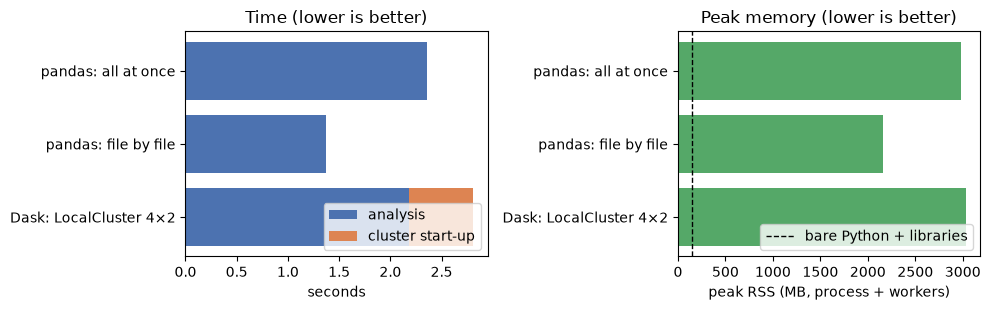

busiest hour 18:00 | highest mean card tip % at 3:00 (32.5% of the fare)


In [47]:
names = list(runs)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].barh(names, [runs[n]["analysis_s"] for n in names], color="#4C72B0", label="analysis")
axes[0].barh(names, [runs[n]["startup_s"] for n in names], left=[runs[n]["analysis_s"] for n in names], color="#DD8452", label="cluster start-up")
axes[0].set(xlabel="seconds", title="Time (lower is better)")
axes[0].legend(loc="lower right")
axes[1].barh(names, [runs[n]["peak_mb"] for n in names], color="#55A868")
axes[1].axvline(bare_mb, color="black", linestyle="--", linewidth=1, label="bare Python + libraries")
axes[1].set(xlabel="peak RSS (MB, process + workers)", title="Peak memory (lower is better)")
axes[1].legend(loc="lower right")
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

hour_table = reference_tables["hour"]
print(f"busiest hour {hour_table.loc[hour_table['trips'].idxmax(), 'hour']}:00 | highest mean card tip % at "
      f"{hour_table.loc[hour_table['mean_card_tip_pct'].idxmax(), 'hour']}:00 ({hour_table['mean_card_tip_pct'].max():.1%} of the fare)")

### Step 6 — Conclusions computed from the measurements

In [48]:
all_at_once, dask_run = runs["pandas: all at once"], runs["Dask: LocalCluster 4×2"]
total_s = {n: r["analysis_s"] + r["startup_s"] for n, r in runs.items()}
pandas_names = [n for n in runs if n.startswith("pandas")]
best_pandas_time = min(pandas_names, key=total_s.get)
best_pandas_memory = min(pandas_names, key=lambda n: runs[n]["peak_mb"])
dask_total = total_s["Dask: LocalCluster 4×2"]

print(f"1. Time (analysis + start-up): fastest overall was {min(total_s, key=total_s.get)}. Dask took {dask_total:.2f} s "
      f"(including {dask_run['startup_s']:.2f} s to start its cluster) vs {total_s[best_pandas_time]:.2f} s for the fastest pandas "
      f"version ({best_pandas_time}).")
print(f"2. Memory: lowest peak was {min(runs, key=lambda n: runs[n]['peak_mb'])}. Dask's 5 processes together peaked at "
      f"{dask_run['peak_mb']:,.0f} MB vs {runs[best_pandas_memory]['peak_mb']:,.0f} MB for {best_pandas_memory} "
      f"(RSS double-counts shared libraries across processes, so Dask's figure is an upper bound).")

mb_per_million_rows = (all_at_once["peak_mb"] - bare_mb) / (TOTAL_ROWS / 1e6)
rows_per_month = TOTAL_ROWS / len(FILES)
months_to_half_ram = (0.5 * TOTAL_RAM_GB * 1024) / (mb_per_million_rows * rows_per_month / 1e6)
print(f"3. pandas all at once needed ≈ {mb_per_million_rows:,.0f} MB per million rows for this pipeline → about "
      f"{months_to_half_ram:.0f} months of yellow-taxi data would use half of this machine's {TOTAL_RAM_GB:.0f} GiB.")

dask_faster = dask_total < total_s[best_pandas_time]
dask_leaner = dask_run["peak_mb"] < runs[best_pandas_memory]["peak_mb"]
fits = all_at_once["peak_mb"] < 0.25 * TOTAL_RAM_GB * 1024
if not dask_faster and not dask_leaner:
    print(f"4. Verdict: for 3 months Dask is NOT worth it on this laptop — {best_pandas_time} was faster and {best_pandas_memory} "
          "used less memory, with far less machinery. Cluster start-up and per-task overhead outweigh the parallelism.")
elif dask_faster and fits:
    gain = total_s[best_pandas_time] / dask_total
    print(f"4. Verdict: Dask was {gain:.1f}× faster than the best pandas version, but the data fits comfortably in memory — "
          f"{'a gain worth having for a job that runs often' if gain >= 1.5 else 'too small a gain to justify a cluster for a one-off job'}.")
else:
    print("4. Verdict: Dask helps here — pandas is either slower or too close to the memory limit for comfort.")
print(f"5. Dask becomes the right tool when the data approaches ~{months_to_half_ram:.0f}+ months (memory), when per-file work is "
      "CPU-heavy Python (worker processes beat the GIL, section 9), or when the same code must run on a cluster.")

1. Time (analysis + start-up): fastest overall was pandas: file by file. Dask took 2.81 s (including 0.63 s to start its cluster) vs 1.37 s for the fastest pandas version (pandas: file by file).
2. Memory: lowest peak was pandas: file by file. Dask's 5 processes together peaked at 3,030 MB vs 2,156 MB for pandas: file by file (RSS double-counts shared libraries across processes, so Dask's figure is an upper bound).
3. pandas all at once needed ≈ 297 MB per million rows for this pipeline → about 13 months of yellow-taxi data would use half of this machine's 24 GiB.
4. Verdict: for 3 months Dask is NOT worth it on this laptop — pandas: file by file was faster and pandas: file by file used less memory, with far less machinery. Cluster start-up and per-task overhead outweigh the parallelism.
5. Dask becomes the right tool when the data approaches ~13+ months (memory), when per-file work is CPU-heavy Python (worker processes beat the GIL, section 9), or when the same code must run on a clus

**Stretch goals**
1. Add more months (download 2024-04 to 2024-06) and plot peak memory and time vs number of months for each implementation. Where do the lines cross?
2. Vary the cluster: 1×8, 2×4, 8×1 workers × threads. Which is fastest for this pandas-heavy workload, and why?
3. Replace the Dask implementation with **Polars streaming** (`scan_parquet(files)...collect(engine="streaming")`) in a fresh process and compare.
4. Make the pandas file-by-file version parallel with `concurrent.futures.ProcessPoolExecutor` and compare it with Dask — how much of Dask's value is the scheduler vs the API?

### 🗣️ How to talk about this in an interview
- "I benchmarked the same pipeline three ways on 9.5 M real taxi trips — pandas all at once, a pandas file-by-file loop, and a 4-worker Dask LocalCluster — each in a fresh process, measuring wall time and peak RSS across all worker processes."
- "All three produced identical aggregates, which I asserted before comparing numbers; the aggregation is written as sums and counts so it combines correctly across chunks."
- "The baseline to beat was a plain pandas file-by-file loop. In my runs on three months, Dask didn't clearly beat it on time or peak memory — cluster start-up and per-task overhead ate the parallel gains — so I wouldn't introduce a cluster at this size."
- "I extrapolated memory per million rows to estimate when pandas stops fitting, and I'd reach for Dask when data outgrows one machine, when per-file work is GIL-bound Python, or when we need a cluster."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is Dask, and how does it differ from Spark?**

<details><summary>Show answer</summary>

- **30-second answer:** Dask is a Python-native parallel computing library: it builds task graphs and runs them on threads, processes, or a distributed cluster, with NumPy-, pandas-, and custom-Python-shaped APIs. Spark is a JVM-based cluster engine centred on DataFrames/SQL with a mature optimizer and ecosystem.
- **Go deeper:** Dask integrates directly with the PyData stack (pandas partitions, NumPy chunks, Xarray, scikit-learn via joblib) and parallelizes arbitrary Python via delayed/futures; Spark shines for very large SQL-style ETL and on platforms like Databricks. Both use lazy plans, partitions, and shuffles. Dask DataFrame now has a query optimizer too.
- **❌ Common wrong answer:** "Dask is just a faster pandas." It's a scheduler for parallel work; on data that fits in memory it's often slower than pandas.

</details>

**Q2. What is a task graph, and why is laziness useful?**

<details><summary>Show answer</summary>

- **30-second answer:** A DAG of function calls and their dependencies. Building it lazily lets the scheduler see all the work first, run independent tasks in parallel, share common intermediate results, and free memory once results are no longer needed.
- **Go deeper:** For DataFrames, the optimizer also rewrites the expression (projection pushdown into Parquet, combining steps) before generating tasks. Very large graphs (millions of tasks) slow the scheduler itself — prefer fewer, larger partitions.
- **❌ Common wrong answer:** "Lazy just means it runs later, there's no benefit."

</details>

**Q3. What is a shuffle, and why is it expensive?**

<details><summary>Show answer</summary>

- **30-second answer:** Moving rows between partitions so that equal keys land together, needed for sorts, `set_index`, large joins, exact `nunique`/`median`, and `groupby.apply`. It's all-to-all: every partition can send to every other, which costs network, serialization, disk spill, and memory.
- **Go deeper:** Reduce it by filtering and projecting first, using decomposable aggregations, broadcast-joining small tables, keeping data partitioned by the join key (known divisions), and persisting after a necessary `set_index`. Skewed keys create straggler partitions.
- **❌ Common wrong answer:** "A shuffle randomly reorders rows" — it's deterministic repartitioning by key.

</details>

**Q4. `persist()` vs `compute()` — when do you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** `compute()` executes and returns a local pandas/NumPy result (must fit in the client process). `persist()` executes and keeps the data in worker memory as a Dask collection, so later queries reuse it instead of recomputing from source.
- **Go deeper:** Persist a cleaned, reduced dataset you'll query repeatedly; it blocks further optimizer pushdown into the reader, and holds worker memory until you drop references. Use `dask.compute(a, b)` to share work between results computed together.
- **❌ Common wrong answer:** "persist saves to disk" — it keeps results in cluster memory (spilling to disk only under memory pressure).

</details>

**Q5. Threads, processes, or distributed — how do you choose a scheduler?**

<details><summary>Show answer</summary>

- **30-second answer:** Threads for NumPy/pandas/Arrow work that releases the GIL (low overhead, shared memory); processes for pure-Python GIL-bound work; distributed for anything needing multiple machines, diagnostics, futures, or memory management — it also works well on one machine.
- **Go deeper:** Processes pay start-up and serialization costs, so they only win when each task's pure-Python work is large enough to outweigh them — sections 8 and 9 measure both cases on this laptop. Distributed workers can mix both: N processes × M threads.
- **❌ Common wrong answer:** "Always use processes to avoid the GIL."

</details>

**Q6. What are divisions in a Dask DataFrame?**

<details><summary>Show answer</summary>

- **30-second answer:** The sorted index boundaries of each partition. When known (after `set_index` or reading sorted, partitioned data), Dask can prune partitions for `.loc` lookups and do fast index-aligned joins without a shuffle.
- **Go deeper:** Most reads start with unknown divisions; `set_index` computes them via sampling/sorting (a shuffle). Skewed or out-of-range values (like a 2002 timestamp) make partitions uneven.
- **❌ Common wrong answer:** "Divisions are the number of partitions."

</details>

**Q7. When should you NOT use Dask?**

<details><summary>Show answer</summary>

- **30-second answer:** When the data fits comfortably in memory and the work is already vectorized — pandas, Polars, or DuckDB will be simpler and usually faster. Also when a single SQL engine or a warehouse already does the job.
- **Go deeper:** Dask adds per-task scheduling overhead, cluster start-up, serialization, and operational complexity; it doesn't make a single-threaded pandas `apply` magically fast. Shrink the data first (columns, filters, dtypes) and measure, as in the mini project.
- **❌ Common wrong answer:** "Whenever the data is over 1 GB."

</details>

### 💻 Coding

**Q8. How does Dask compute `groupby("zone").fare.mean()` across partitions? Write the idea without Dask.**

<details><summary>Show answer</summary>

- **30-second answer:** Per partition compute `sum` and `count` per zone; concatenate the partial results and `groupby(level=0).sum()`; divide sum by count. Never average partition means.
- **Go deeper:** That's a tree reduction (`split_every` controls fan-in). For many groups, `split_out` hashes keys into several output partitions. Median/nunique need a shuffle or approximate sketches.
- **❌ Common wrong answer:** `mean([partition.mean() for partition in parts])` — wrong when partitions or groups have different sizes.

</details>

**Q9. You have 5,000 CSV files and a function `process(path) -> DataFrame`. Parallelize it with Dask.**

<details><summary>Show answer</summary>

- **30-second answer:** `parts = [dask.delayed(process)(p) for p in paths]` then either `dd.from_delayed(parts, meta=...)` to get a Dask DataFrame, or `client.map(process, paths)` with futures; compute aggregates rather than bringing all rows back.
- **Go deeper:** Batch tiny files so each task does meaningful work, pass `meta` for `from_delayed`, choose processes if `process` is pure Python, and write results to Parquet (`to_parquet`) instead of `compute()`-ing everything. `dd.read_csv(glob, blocksize=...)` is simpler if it's a plain CSV read.
- **❌ Common wrong answer:** `delayed(process_all)(all_paths)` — a single task, no parallelism.

</details>

**Q10. How do you compute several results from the same lazy DataFrame efficiently?**

<details><summary>Show answer</summary>

- **30-second answer:** Pass them all to one `dask.compute(r1, r2, r3)` call so shared steps (like reading and filtering the files) run once — or `persist` the shared intermediate if you'll run many queries over time.
- **Go deeper:** Separate `.compute()` calls re-execute the whole graph each time (we measured ~3× slower for four results). On a cluster, persisted data plus futures lets interactive sessions stay fast.
- **❌ Common wrong answer:** "Call `.compute()` on the DataFrame once and use pandas" — only works if it fits in memory, which defeats the purpose.

</details>

### 🐛 Debugging Scenarios

**Q11. Dask workers keep dying with "worker exceeded 95% memory budget". What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Partition size vs worker memory (partition × threads × intermediate copies), large shuffles or skewed keys, `persist`ed collections nobody released, and calls that pull big results to one place (`compute()` of raw rows, `groupby.apply` returning large frames).
- **Go deeper:** Repartition to ~100 MB, reduce threads per worker or increase memory per worker, select columns and filter before shuffles, use `split_out` for large group-bys, check the dashboard's worker memory and task stream, and look for unmanaged memory (e.g. fragmentation) vs managed data.
- **❌ Common wrong answer:** "Add more workers" — if a single partition or a skewed group is too big, more workers don't help.

</details>

**Q12. After switching a Parquet read to use `filters=`, your row counts dropped to zero, but no error was raised. How do you debug it?**

<details><summary>Show answer</summary>

- **30-second answer:** Compare against an independent count (pyarrow, Polars, DuckDB, or an expression filter on the same data). Check the file metadata — whether row-group statistics exist — and the reader options (`split_row_groups`, engine, filesystem). Keep the expression-based filter until the pushed-down one is proven equivalent.
- **Go deeper:** Pushdown relies on metadata and engine code paths that can differ between versions; add row-count reconciliation tests to pipelines. In this notebook's Dask version, the default path returned 0 rows on statistics-less TLC files while `split_row_groups="adaptive"` and expression filters were correct.
- **❌ Common wrong answer:** "Filters are just an optimization, they can't change results" — a buggy or misconfigured pushdown can.

</details>

**Q13. A Dask job is slower than the pandas version on the same laptop. Why might that be, and is it a problem?**

<details><summary>Show answer</summary>

- **30-second answer:** Cluster start-up, per-task scheduling overhead, serialization between processes, too many small partitions, or shuffles — while pandas does the same vectorized work in one process with no coordination. If the data fits comfortably, it's not a problem to fix — it's a signal to use pandas/Polars/DuckDB.
- **Go deeper:** Profile with the dashboard (task stream, transfer time), reduce partition count, use threads for GIL-releasing work, avoid `compute()` in loops, and compare end-to-end including start-up, as in the mini project.
- **❌ Common wrong answer:** "Dask is always faster because it's parallel."

</details>

### 🏗️ Design

**Q14. Design a daily job that aggregates 2 TB of new Parquet event logs into per-user features. Which tools, and how?**

<details><summary>Show answer</summary>

- **30-second answer:** Partition input by date (and maybe hour); read only the new partitions with column projection; compute decomposable aggregations per user with a distributed engine (Spark or Dask on an autoscaling cluster; a warehouse like BigQuery/Snowflake if data is already there); write results to date-partitioned Parquet; validate row counts and null rates before publishing.
- **Go deeper:** Avoid full shuffles by hashing users into a fixed number of buckets, use incremental state (yesterday's aggregates + today's events), size partitions ~100 MB–1 GB, handle skewed heavy users, make runs idempotent (overwrite a date partition), and monitor cost and runtime. Test on a sample first — maybe a single large machine with Polars/DuckDB is enough.
- **❌ Common wrong answer:** "Load everything into pandas on a big VM every day" or "recompute all history daily."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `da.ones((10, 10), chunks=(5, 5)).numblocks`
<details><summary>Answer</summary>

`(2, 2)` — each 10-long axis is split into two 5-long chunks, giving 4 blocks.
</details>

**2.** `x = dask.delayed(sum)([1, 2, 3])` — what is `type(x).__name__`, and what does `x.compute()` return?
<details><summary>Answer</summary>

`Delayed`, then `6` — calling a delayed function only records a task until you compute it.
</details>

**3.** Which of these needs a shuffle: `ddf.groupby("k")["v"].sum()` or `ddf.set_index("k")`?
<details><summary>Answer</summary>

`ddf.set_index("k")` — sorting by a new index moves rows between partitions. A group-by `sum` is a tree reduction of per-partition sums.
</details>

**4.** `dd.from_pandas(pd.DataFrame({"x": range(10)}), npartitions=2).known_divisions`
<details><summary>Answer</summary>

`True` — `from_pandas` sorts by the (range) index and records each partition's index boundaries.
</details>

**5.** For a Dask DataFrame read from Parquet, do `len(ddf)` and `ddf.shape[0].compute()` do different amounts of work?
<details><summary>Answer</summary>

**No** — both compute the row count (in this Dask version, straight from Parquet metadata). The expensive mistake is `len(ddf.compute())`, which loads every row first.
</details>

## 📚 Resources

### 📖 Official Docs
- [Dask — Dask documentation](https://docs.dask.org/en/stable/) — overview of collections and schedulers
- [Dask DataFrames Best Practices — Dask documentation](https://docs.dask.org/en/stable/dataframe-best-practices.html) — partition sizes, persist, when to use pandas instead
- [Dask Dataframe and Parquet — Dask documentation](https://docs.dask.org/en/stable/dataframe-parquet.html) · [Optimizer — Dask documentation](https://docs.dask.org/en/stable/dataframe-optimizer.html) · [Shuffling Performance — Dask documentation](https://docs.dask.org/en/stable/dataframe-groupby.html)
- [Chunks — Dask documentation](https://docs.dask.org/en/stable/array-chunks.html) — choosing chunk sizes for arrays
- [Dask Delayed — Dask documentation](https://docs.dask.org/en/stable/delayed.html) · [Best Practices — Dask documentation](https://docs.dask.org/en/stable/delayed-best-practices.html) (delayed)
- [Futures — Dask documentation](https://docs.dask.org/en/stable/futures.html) · [Dask.distributed — Dask.distributed documentation](https://distributed.dask.org/en/stable/) · [Dashboard Diagnostics — Dask documentation](https://docs.dask.org/en/stable/dashboard.html)
- [Comparison to Spark — Dask documentation](https://docs.dask.org/en/stable/spark.html) — the maintainers' own honest comparison
- Dataset: [TLC Trip Record Data - TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

### 🎥 Videos
- [Dask — Dask DataFrame: An Introduction](https://www.youtube.com/watch?v=AT2XtFehFSQ) (7 m) — the official short intro to partitions and the pandas-like API; watch it first
- [Enthought — Dask Parallel and Distributed Computing | SciPy 2016 | Matthew Rocklin](https://www.youtube.com/watch?v=PAGjm4BMKlk) (28 m) — Dask's creator on task graphs and schedulers, the ideas behind sections 2 and 9
- [PyData — Matthew Rocklin | Using Dask for Parallel Computing in Python](https://www.youtube.com/watch?v=s4ChP7tc3tA) (44 m) — a longer walkthrough of delayed, arrays, dataframes, and the distributed scheduler

### 📄 Papers
- [Rocklin (2015) — Dask: Parallel Computation with Blocked algorithms and Task Scheduling (SciPy)](https://proceedings.scipy.org/articles/Majora-7b98e3ed-013) — the original Dask paper
- [Dean & Ghemawat (2004) — MapReduce: Simplified Data Processing on Large Clusters](https://research.google/pubs/mapreduce-simplified-data-processing-on-large-clusters/) — the map → shuffle → reduce model every distributed engine inherits
- [Zaharia et al. (2012) — Resilient Distributed Datasets (NSDI)](https://www.usenix.org/system/files/conference/nsdi12/nsdi12-final138.pdf) — the paper behind Spark, useful for the Dask-vs-Spark discussion

### 📘 Books & Courses
- [Dask Tutorial — Dask Tutorial documentation](https://tutorial.dask.org/) — the official hands-on tutorial notebooks
- [Dask DataFrame is Fast Now — Coiled documentation](https://docs.coiled.io/blog/dask-dataframe-is-fast.html) — how the query optimizer and new shuffle changed Dask DataFrame performance

### 🏋️ Practice
- [Dask Examples — Dask Examples documentation](https://examples.dask.org/) — runnable examples for arrays, dataframes, delayed, futures, and machine learning
- [TLC Trip Record Data - TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) — scale the mini project to a full year or to for-hire-vehicle data (much larger) and re-measure

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Task graph | lazy DAG of function calls | `dask.delayed`, `.compute()`, `dask.compute(a, b)` (share work) |
| dask.array | chunked NumPy | `da.from_delayed`, `.chunks`, `.rechunk`, `.map_blocks` |
| dask.dataframe | partitioned pandas | `dd.read_parquet(columns=…)`, `.npartitions`, `.partitions[i]`, `.pprint()`, `.optimize()` |
| Custom pandas per partition | escape hatch | `map_partitions(fn, meta=…)` |
| Cheap aggregations | tree reduction | `groupby().agg(sum/count/mean/min/max)`, `split_out=` |
| Shuffles | move rows by key (expensive) | `set_index`, `sort_values`, big `merge`, `nunique`/`median`, `groupby.apply` |
| Divisions | index boundaries → pruning | `known_divisions`, `set_index` once, then `.loc[...]` |
| Futures | eager background tasks | `client.submit/map/gather`, `as_completed` |
| Schedulers | where tasks run | threads (GIL-releasing) · processes (pure Python) · `LocalCluster` + `Client` |
| persist vs compute | cluster memory vs local result | `persist()` + `wait()`, `compute()`, `del` to release |
| Sizing | memory safety | ~100 MB partitions, `repartition(partition_size=…)`, worker memory thresholds |
| Validation | trust but verify | independent row counts after pushdown (`filters=` pitfall) |
| Decision | right tool | fits in RAM → pandas/Polars/DuckDB; parallel Python or cluster → Dask; big JVM/SQL ETL → Spark |

## ➡️ What's Next

**[12 · Optuna](../12_AutoML_Experimentation/01_Optuna.ipynb)** — you can now prepare large datasets efficiently; next you'll tune the models trained on them, where many independent trials are another naturally parallel workload.